In [1]:
import os
os.environ['ARTS_DATA_PATH'] = '/home/pc2943/arts-cat-data/'

import matplotlib.pyplot as plt
import numpy as np

import konrad

import xarray as xr

import metpy.calc as mpcalc
from metpy.units import units

import pyarts

import seaborn as sns

import scipy as sp
from scipy.constants import speed_of_light as c
import scipy.constants

import colorcet as cc

from pyarts import xml
import typhon

import matplotlib.colors as colors

from numpy import meshgrid, deg2rad, gradient, cos
from xarray import DataArray

from matplotlib import gridspec

import cartopy as cp
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from   cartopy.feature import LAND
from   cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import scipy.stats as stats

constant_k = 1.380649e-23

/home/pc2943/.conda/envs/konrad/lib/python3.9/site-packages/typhon/nonlte/rtc/__init__.py:41: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  FOSC = numba.jit(FOSC)


In [2]:
# TNR font
plt.rcParams['font.family'] = ['serif']
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams["mathtext.fontset"] = 'stix'
plt.rcParams['text.usetex'] = False
plt.rc('axes', titlesize=18)     # fontsize of the axes title
plt.rc('axes', labelsize=18)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=14)    # fontsize of the tick labels
plt.rc('ytick', labelsize=14)    # fontsize of the tick labels
plt.rc('legend', fontsize=16)    # legend fontsize
plt.rc('figure', titlesize=20)  # fontsize of the figure title



In [3]:
### absorption functions used throughout

# calculate fluxes using ARTS
def calc_lbl_rt(atmosphere, species = ["CH4"], w_grid = np.linspace(10, 3260, 30000)):
    """
    Calculate fluxes and optical depth with ARTS
    
    In:
        atmosphere: ARTS atmosphere with associated temperatures, pressures, and gas concentrations (vmr)
        species: list of ARTS line species
        w_grid [cm-1]: wavenumbers
    
    Out:
        flux_up [W/m^2]
        flux_down [W/m^2]
        int_flux_up [W/m^2]: integrated across wavenumber
        int_flux_down [W/m^2]: integrated flux down
        tau: layer optical depth for each layer (needs to be cumulatively summed)
        absorption_coeff [1/m]: linear absorption coefficient
    """

    from scipy.constants import speed_of_light as c


    # Create ARTS workspace and load default settings
    ws = pyarts.workspace.Workspace(verbosity=0)
    ws.water_p_eq_agendaSet()
    ws.gas_scattering_agendaSet()
    ws.PlanetSet(option="Earth")

    # set verbosity
    ws.verbositySetScreen(ws.verbosity, 0)
    
    # Number of Stokes components to be computed
    ws.IndexSet(ws.stokes_dim, 1)

    # We do not want to calculate the Jacobian Matrix
    ws.jacobianOff()   

    # Clearsky = No scattering
    ws.cloudboxOff()

    # Define absorption species
    ws.abs_speciesSet(species=species)
    ws.abs_lines_per_speciesReadSpeciesSplitCatalog(basename="lines/")
    
    # Read cross section data
    ws.ReadXsecData(basename="xsec/")

    # Create a frequency grid from wavenumber
    ws.f_grid = pyarts.arts.convert.kaycm2freq(w_grid)

    # Throw away lines outside f_grid
    ws.abs_lines_per_speciesCompact()
    ws.abs_lines_per_speciesCutoff(option="ByLine", value=750e9)
    ws.abs_lines_per_speciesNormalization(option="SFS")

    ws.abs_lines_per_speciesTurnOffLineMixing()

    # Calculate absorption
    ws.propmat_clearsky_agendaAuto(T_extrapolfac = 1E99)

    # Weakly reflecting surface
    ws.VectorSetConstant(ws.surface_scalar_reflectivity, 1, 0.0)

    ws.atm_fields_compact = atmosphere
    # Atmospheric settings
    ws.AtmosphereSet1D()
    ws.AtmFieldsAndParticleBulkPropFieldFromCompact()
    
    # Set surface height and temperature equal to the lowest atmosphere level
    ws.Extract(ws.z_surface, ws.z_field, 0)
    ws.surface_skin_t = ws.t_field.value[0, 0, 0]
    ws.vmr_field.value = ws.vmr_field.value.value.clip(min=0.0)
                                                       
    # Output radiance not converted
    ws.StringSet(ws.iy_unit, "1")

    # set cloudbox to full atmosphere
    ws.cloudboxSetFullAtm()

    # set particle scattering to zero, because we want only clear sky
    ws.scat_data_checked = 1
    ws.Touch(ws.scat_data)
    ws.pnd_fieldZero()

    # No sensor properties
    ws.sensorOff()

    # No jacobian calculations
    ws.jacobianOff()

    # Check model atmosphere
    ws.scat_data_checkedCalc()
    ws.atmfields_checkedCalc()
    ws.atmgeom_checkedCalc()
    ws.cloudbox_checkedCalc()
    ws.lbl_checkedCalc()
    
    # record optical depth
    ws.disort_aux_vars = ["Layer optical thickness"]

    # Perform RT calculations
    ws.DisortCalcIrradiance(nstreams=2, emission=1)

    flux_up = ws.spectral_irradiance_field.value[:, :, 0, 0, 1] # OLR is last entry (pressure high to low)
    flux_down = ws.spectral_irradiance_field.value[:, :, 0, 0, 0]
    # convert from frequency to wavenumber
    flux_up = (flux_up * (c * 100))[:, :]
    flux_down = np.abs((flux_down * (c * 100))[:, :])
    
    # integrate
    int_flux_up = np.trapz(flux_up.T, w_grid, axis = 1)
    int_flux_down = np.trapz(flux_down.T, w_grid, axis = 1)
    
    # retrieve optical depth
    tau=ws.disort_aux.value[0].value    
    
    ws.propmat_clearsky_fieldCalc()    

    # retrieve linear absorption coefficient
    absorption_coeff = ws.propmat_clearsky_field.value[:, :, 0, 0, :, 0, 0].copy()

    return flux_up, flux_down, int_flux_up, int_flux_down, tau, absorption_coeff

# convert absorption cross section to mass absorption coefficient
def xsec_to_mass_absorption(xsec, molar_mass):
    """
    Convert absorption cross section to mass absorption coefficient
    
    In: 
        xsec: absorption cross section
        molar_mass [kg/mol]

    Out:
        mass absorption coefficient [m^2/kg]
    """
    
    return (scipy.constants.N_A/molar_mass)*xsec

# convert linear absorption coefficient to absorption cross section
def absorption_coeff_to_xsec(coeff, pressure, vmr, temperature):
    """
    Convert linear absorption coefficient to absorption cross section

    In: 
        coeff [1/m]: linear absorption coefficient
        pressure [Pa]
        vmr [dimensionless]: volume mixing ratio corresponding to absorption coefficient
        temperature [K]

    Out:
        absorption cross section: absorption coefficient divided by number density

    """
    N = pressure * vmr / (constant_k* temperature)
    return coeff/N

# linear optical depth
def tau_nu(p, k_ref, q):
    '''
    Calculate optical depth
    
    In:
        p [Pa]: pressure at which to compute optical depth
        k_ref [m^2/kg]: the mass absorption coefficient at a reference pressure and temperature
        q: the mass concentration: vmr * molar mass of constituent / molar mass of dry air

    Out: 
        cumulative optical depth at pressure level p
    '''
    D = 2 # two-stream coeff.
    g = 9.81 # acceleration due to gravity
    return (D*k_ref*q*(p))/(g)

# draw idealized exponential absorption coefficient
def k(k_0, nu_0, l, wavenumbers):
    """
    calculate idealized exponential absorption coefficient
    
    In:
        k_0 [m^2/kg]: height of peak of the absorption band
        nu_0 [cm-1]: center of the band or where peak is, in wavenumber
        l [cm-1]: exponential slope of the coefficient
        wavenumbers [cm-1]: wavenumber range across which to calculate

    Out:
        k [m^2/kg]
    """
    return k_0 * np.exp(-(np.abs(wavenumbers - nu_0*np.ones(len(wavenumbers)))/l))

# create idealized moist-adiabatic profile
def create_profile_moist(T_s, rh, p):
    ''' 
    create an idealized profile with given surface temperature that follows
    a moist adiabatic lapse rate until a 200K isothermal stratosphere

    IN:
        T_s [K]: given surface temperature
        rh [%]: given relative humidity, constant throughout atmosphere
        
    OUT:
        T_profile [K]: temperature profile
        vmr [unitless]: water vapor volume mixing ratio
        q_star_s [kg/kg]: saturation mass mixing ratio of water vapor at the surface        
    
    '''
    T_s = units.Quantity(T_s, 'K')
    #rh = units.Quantity(rh, 'dimensionless')
    # create pressure, temperature, and mixing ratio profiles for each initial temp
    pressure_profile = units.Quantity(p, 'Pa')
    pressure_profile_temp = p[np.where(p > 100)[0]]
    pressure_profile_temp = units.Quantity(pressure_profile_temp, 'Pa')
    p_s = units.Quantity(p[0], 'Pa')

    temperature = mpcalc.moist_lapse(pressure_profile_temp, T_s, p_s)
    idx = np.where(temperature > units.Quantity(200, 'K'))[0]
    T_profile = units.Quantity(200, 'K')*np.ones(len(p))
    T_profile[:idx[-1] + 1] = temperature[idx]

    mass_mixing_ratio = mpcalc.mixing_ratio_from_relative_humidity(pressure_profile, T_profile, rh).to('kg/kg') 
    q_star_s = mpcalc.saturation_mixing_ratio(p_s, T_profile[0]).to('kg/kg')

    # mmr = vmr * molar mass / molar mass of dry air
    vmr = mass_mixing_ratio * (29 / 18.015)       
    
    return T_profile, vmr, q_star_s

# water vapor line absorption optical depth
def line_tau(k_line, p, p_ref, T, rh):
    """
    Jeevanjee et al. 2021 kappa-/tau-
    optical depth due to foreign-continuum/line absorption of water vapor

    In:
        k_line [m^2/kg]: water vapor line/foreign absorption coefficient
        p [Pa]: pressure profile
        p_ref [Pa]: reference pressure level
        T [K]: temperature profile
        rh [%]: relative humidity

    Out:
        optical depth
    """    

    # constants (listed in paper Table 2)
    D = 2  # two-stream hemispheric integration 
    p_inf = 2.5 * (10**11) # reference saturation vapor pressure [Pa]
    L = 2.5 * (10**6) # specific heat of vaporisation [J/kg]
    cp = 1004 # heat capacity [J/kgK]
    g = 9.8 # acceleration due to gravity [m/s^2]
    T_av = 0.5*(T[0] + np.min(T)) # linear average temperature [K]
    gamma = g/cp # dry adiabatic lapse rate [K/m]
    R_v = 461 # gas constant for water vapor [J/kgK]
    wvp0 = (T_av*rh*p_inf)/(gamma*L) # reference water vapor path
    
    return (D*k_line*(p/p_ref)*wvp0*np.exp(-L/(R_v*T)))

# water vapor self-continuum absorption optical depth
def cont_tau(k_cont, T, T_ref, rh, rh_ref):
    """
    Jeevanjee et al. 2021 kappa+/tau+
    optical depth due to self-continuum absorption of water vapor

    In:
        k_cont [m^2/kg]: water vapor self absorption coefficient
        T [K]: temperature profile
        T_ref [K]: reference temperature
        rh [%]: relative humidity
        rh_ref [%]: reference relative humidity

    Out:
        optical depth
    """    
        
    # constants
    L = 2.5 * (10**6) # specific heat of vaporisation [J/kg]
    p_inf = 2.5 * (10**11) # reference saturation vapor pressure [Pa]
    D = 2 # two-stream hemispheric integration 
    cp = 1004 # heat capacity [J/kgK]
    g = 9.8 # acceleration due to gravity [m/s^2]
    gamma = g/cp    # dry adiabatic lapse rate [K/m]
    R_v = 461 # gas constant for water vapor [J/kgK]

    sigma = 0.02 # vapor pressure scaling coefficient [K-1]
    alpha0 = L/(R_v*(T_ref**2)) # vapor pressure scaling
    alpha = 2*alpha0 - sigma # from Clausius-Clapeyron
    
    svp = p_inf*np.exp(-L/(R_v*T_ref)) # saturation vapor pressure
    rho_star_ref = svp/(R_v*T_ref) # saturation vapor density
    
    return (D*(rh**2)*rho_star_ref*k_cont*np.exp(alpha*(T-T_ref)))/(rh_ref*gamma*alpha)

# cumulative sum of optical depth 
def arts_tau_to_cumulative(arts_tau):
    """
    cumulative sum of optical depth

    In:
        arts_tau: non-cumulative optical depth out of ARTS

    Out:
        cumulative optical depth
    """
    return np.cumsum(arts_tau[:, ::-1], axis = 1)[:, ::-1]

# Planck function
def B_nu(T, nu):
    """
    Planck function
    
    In:
    T [K]: temperature
    nu [cm-1]: multiply all nu's by 100 to convert to m-1 in formula, then multiply
               B by 100 for units of W/m^2/sr/cm-1
        
    Out:
        Planck function in units of W/m^2/sr/cm-1
    """
    k_B = scipy.constants.k # Boltzmann constant
    h = scipy.constants.h # Planck constant
    c = scipy.constants.speed_of_light # speed of light in a vacuum
    
    return ((2*h*(c**2)*((100*nu)**3))/(np.exp((h*c*(100*nu))/(k_B*T)) - 1))*100

# calculate transmittance
def Transmittance(tau_1, tau_2):
    """
    Transmittance between two optical depth levels

    In: 
        tau_1: optical depth at level 1
        tau_2: optical depth at level 2

    Out:
        Transmissivity
    """
    return np.exp(-np.abs(tau_1 - tau_2))

# Schwarzschild's equation solver for upward flux at one pressure
def flux_up(T, p, tau, nu):
    """
    Solve Schwartzschild's equations at one pressure
    Inputs ordered from ground to TOA
    
    In: 
        T [K]: temperature profile 
        p [Pa or hPa]: pressure profile
        tau: cumulative optical depth from TOA
        nu [cm-1]: wavenumbers
    
    Out:
        flux up [W/m^2] across wavembers
    """

    # emissivity
    e = 1
    
    # if only one level
    if len(p) == 1:
        return np.pi*e*(Transmittance(tau[-1], tau[0]))*B_nu(T[0], nu)
    
    # transmissivity matrix for each wavenumber and pressure
    transmittance_matrix = np.zeros((len(p), len(nu)))
    for i in range(len(p)):
        transmittance_matrix[i, :] = Transmittance(tau[-1], tau[i]) 

    # Planck matrix for each wavenumber and pressure
    Planck_matrix = np.zeros((len(p), len(nu)))
    for i in range(len(p)):
        Planck_matrix[i, :] = B_nu(T[i], nu)

    # derivative
    dtransdp = np.gradient(transmittance_matrix, axis = 0).T/np.gradient(p)
    
    return np.pi*e*(Transmittance(tau[-1], tau[0]))*B_nu(T[0], nu) + np.pi*np.trapz(np.multiply(dtransdp.T, Planck_matrix), p, axis = 0)

# Schwarzschild's equation loop for all pressures
def flux_up_profile(T, p, tau, nu):
    """
    Loop through flux_up function for wavenumber and pressure
    In: 
        T [K]: temperature profile 
        p [Pa or hPa]: pressure profile
        tau: cumulative optical depth from TOA
        nu [cm-1]: wavenumbers
    
    Out:
        flux up [W/m^2] across wavembers and pressure levels
    """

    fluxes_up = np.zeros((len(p), len(nu)))
    for idx in range(len(p)):
        idx = idx + 1
        fluxes_up[idx-1, :] = flux_up(T[:idx], p[:idx], tau[:idx], nu)
    return fluxes_up

# moving average helper function
def moving_average_numpy(data, window):
    """
    Take a moving average of some data in a given window
    In:
        data: array
        window: how many indeces to average over

    Out:
        averaged data
    """
    weights = np.repeat(1.0, window) / window
    return np.convolve(data, weights, mode='valid')

# average absorption coefficient
def mvt_coeff(p_idx, mass_abs, band):
    """  
    calculate \int \kappa d\nu / \int d\nu
    In:
        p_idx: index of reference pressure level
        mass_abs: mass absorption coefficient (or any array)
        band: wavenumber range (axis of integration)
    
    Out:
        averaged absorption coefficient/data array
    """
    return np.trapz(mass_abs[:, p_idx], band)/(band[-1] - band[0])

# optical thickness at a given wavenumber or pressure
def tau_nu_pressure_broadening(p, k_ref, q, p_ref):
    '''
    Calculate optical depth including the effects of pressure broadening
    
    In:
        p [Pa]: pressure at which to compute optical depth
        k_ref: the mass absorption coefficient at a reference pressure and temperature
        q: the mass concentration: vmr * molar mas of constituent / molar mass of dry air
            here: when k_ref is in volume units, can use q = vmr.
        p_ref [Pa]: reference pressure at which k_ref is computed

    Out:
        optical thickness
    '''
    D = 2 # two-stream coeff.
    g = 9.81 # acceleration due to gravity
    # p is multiplied last to avoid overflow error!!!
    return ((D*k_ref*q*(p))/(2*g*(p_ref)))*p

# optical thickness pressure loop w/ no pressure broadening
def optical_thickness_profile(p, k_ref, q):
    """
    Helper function to calculate \tau profile.

    In:
        p [Pa]: pressure profile
        k_ref [m^2/kg]: mass absorption coefficient
        q [kg/kg]: mass concentration
    Out:
        optical_thickness: optical thickness array in pressure x wavenumber dimensions
    """
    optical_thickness = np.zeros((len(p), len(k_ref)))
    for i in range(len(p)):
        optical_thickness[i, :] = tau_nu(p[i], k_ref, q)
    return optical_thickness

# optical thickness pressure loop w/ pressure broadening
def optical_thickness_profile_p_broad(p, k_ref, q, p_ref):
    """
    Helper function to calculate \tau profile
    In:
        p [Pa]: pressure profile
        k_ref [m^2/kg]: mass absorption coefficient
        q [kg/kg]: mass concentration
        p_ref [Pa]: reference pressure
    Out:
        optical_thickness: optical thickness array in pressure x wavenumber dimensions
    """
    optical_thickness = np.zeros((len(p), len(k_ref)))
    for i in range(len(p)):
        optical_thickness[i, :] = tau_nu_pressure_broadening(p[i], k_ref, q, p_ref)
    return optical_thickness

# wrapper for all optical thickness functions
def tau_profile(p, k, mmr, p_ref, beta):
    """
    Wrapper for all optical thickness functions
    In: 
        p [Pa]: pressure profile
        k [m^2/kg]: mass absorption coefficient in waveumber
        mmr [kg/kg]: mass concentration ratio
        p_ref [Pa]: reference pressure
        beta: 1 or 2, decides whether tau is square or linear in pressure
    Out:
        optical thickness array in pressure x wavenumber dimensions
    """

    if beta == 1:
        return optical_thickness_profile(p, k, mmr)
    elif beta == 2:
        return optical_thickness_profile_p_broad(p, k, mmr, p_ref)
    else:
        print("beta must be 1 or 2")

# compute emission width
def v_em(l, q, k_0, p_ref, p, tau_em, beta):
    """  
    Invert absorption coefficient for emission width
    
    In:
        l [cm-1]: slope of exponential falloff from band center
        q [kg/kg]: mass concentration
        k_0 [m^2/kg]: peak of absorption coefficient
        p_ref [Pa]: reference pressure
        p [Pa]: pressure profile
        tau_em: emission optical thickness (are we measuring at the surface or
            where H2O is emitting)
        beta: 1 or 2, is optical thickness linear or quadratic

    Out:
        v_em [cm-1]: spectral width of emitting wavenumbers
    """
    D = 2 # hemispheric integration
    g = 9.8 # gravity

    # 
    if beta == 2:
        return 2*l*np.log(((D*q*k_0*p)/(2*tau_em*g*p_ref))*p)
    
    elif beta == 1:
        return 2*l*np.log((D*q*k_0*p)/(tau_em*g))


def earth_radius(lat):
    '''
    Earth radius from latitude

    In:
    lat: vector or latitudes in degrees  
    
    
    Out:  
    r: vector of radius in meters

    adapted from lgloege/area_grid.py

    '''

    # define oblate spheroid from WGS84
    a = 6378137
    b = 6356752.3142
    e2 = 1 - (b**2/a**2)
    
    # convert from geodecic to geocentric
    # see equation 3-110 in WGS84
    lat = deg2rad(lat)
    lat_gc = np.arctan( (1-e2)*np.tan(lat) )

    # radius equation
    # see equation 3-107 in WGS84
    r = (
        (a * (1 - e2)**0.5) 
         / (1 - (e2 * np.cos(lat_gc)**2))**0.5 
        )

    return r

def area_grid(lat, lon):
    """
    Calculate the area of each grid cell
    Area is in square meters
    
    In:
    lat: vector of latitude in degrees
    lon: vector of longitude in degrees
    
    Out:
    area: grid-cell area in square-meters with dimensions, [lat,lon]
    
    adapted from lgloege/area_grid.py
    """

    xlon, ylat = meshgrid(lon, lat)
    R = earth_radius(ylat)

    dlat = deg2rad(gradient(ylat, axis=0))
    dlon = deg2rad(gradient(xlon, axis=1))

    dy = dlat * R
    dx = dlon * R * cos(deg2rad(ylat))

    area = dy * dx

    return area


In [4]:
# model functions, as described in the paper text

# monochromatic forcing by an optically-thin gas (Eqn. 4)
def thin_model_monochromatic(T, p, nu, tau_gas_1, tau_gas_2):    
    """
    Calculate the monochromatic forcing by an optically-thin gas

    In:
        T [K]: temperature profile
        p [Pa]: pressure profile
        nu [cm-1]: wavenumber
        tau_gas_1: original optical thickness profile
        tau_gas_2: optical thickness due to perturbation in gas concentration

    Out: 
        Eqn. 4
    """

    Temp_em = T[0] # surface/emission temperature
    B_em = B_nu(Temp_em, nu) # surface Planck function

    # surface optical depth
    tau_1em = tau_gas_1[0]
    tau_2em = tau_gas_2[0]

    # integrate only through tropopause
    T_Trop = np.min(T)
    Trop_idx = np.where(T == T_Trop)[0][0]

    # calculate whole Planck profile
    B_profile = B_nu(T, nu)
    
    # calculate weighted pressure average
    B_bar = np.trapz(B_profile[:Trop_idx], p[:Trop_idx])/np.trapz(np.ones(len(p[:Trop_idx])), p[:Trop_idx])

    # Eqn. 4
    return np.pi*B_em*(tau_2em - tau_1em) - np.pi*B_bar*(tau_2em - tau_1em)

# integrated optically-thin forcing with explicitly-integrated B_bar and
# potential H2O overlap
def thin_model_linear_band_average_Bbar(T, p, band, tau_gas_1, tau_gas_2, central_nu, tau_H2O, tau_em):
    """
    Calculate the band-integrated forcing by an optically-thin gas (Eqn. 6)

    In:
        T [K]: temperature profile
        p [Pa]: pressure profile
        band [cm-1]: span of wavenumbers across which to calculate
        tau_gas_1: optical thickness due to given gas concentration 
        tau_gas_2: optical thickness due to perturbation in gas concentration 
        tau_H2O: optical thickness due to water vapor or otherwise overlapping gas
        tau_em: emission optical depth of overlapping gas

    Out: 
        Eqn. 6
    """

    # if water vapor is emitting:
    if np.max(tau_H2O[:, 0]) > tau_em:
        
        # find where H2O crosses its emission line; doesn't assume sorting
        H2O_em_idx = np.where(tau_H2O[:, 0] >= tau_em)[0]
        border_idx = len(H2O_em_idx)
        H2O_band = band[:border_idx]
        surface_band = band[border_idx:]

        
        # find tropospheric temperature
        T_Trop = np.min(T)
        Trop_idx = np.where(T == T_Trop)[0][0]

        if len(surface_band) > 0:

            sfc_central_idx = round(len(surface_band)/2)
            B_s = B_nu(T[0], central_nu) # surface Planck function

            # calculate forcing in the surface-emission part of the band
            B_profile = B_nu(T, central_nu)
            B_bar_sfc = np.trapz(B_profile[:Trop_idx], p[:Trop_idx])/np.trapz(np.ones(len(p[:Trop_idx])), p[:Trop_idx])

            tau_1em = np.trapz(tau_gas_1[:, 0], band)/(band[-1] - band[0])
            tau_2em = np.trapz(tau_gas_2[:, 0], band)/(band[-1] - band[0])

            sfc_band_width = np.abs(surface_band[-1] - surface_band[0])
            surface_forcing = np.pi*(B_s - B_bar_sfc)*sfc_band_width*(tau_2em - tau_1em)
        else:
            surface_forcing = 0

        # calculate mean emission temperature of H2O
        T_em_H2O = np.empty(len(H2O_em_idx))

        for nu_idx, H2O_idx in enumerate(H2O_em_idx):
            T_em_H2O[nu_idx] = np.max([np.interp(tau_em, tau_H2O[H2O_idx, :Trop_idx][::-1], T[:Trop_idx][::-1]), T_Trop])
            T_em_H2O[nu_idx] = np.min([T_em_H2O[nu_idx], T[0]])

        H2O_band_width = np.abs(H2O_band[-1] - H2O_band[0])
        T_em_mean = np.trapz(T_em_H2O, H2O_band)/H2O_band_width

        H2O_central_idx = round(len(H2O_band)/2)
        p_em_mean = np.interp(T_em_mean, T[:Trop_idx][::-1], p[:Trop_idx][::-1])
        tau_gas_em_1= np.interp(p_em_mean, p[::-1], (np.trapz(tau_gas_1, band, axis = 0)/(band[-1] - band[0]))[::-1])
        tau_gas_em_2= np.interp(p_em_mean, p[::-1], (np.trapz(tau_gas_2, band, axis = 0)/(band[-1] - band[0]))[::-1])

        # emission Planck function of H2O
        B_em = B_nu(T_em_mean, central_nu)
        T_em_idx = np.where(T <= T_em_mean)[0][0]
        
        # B_bar between level where H2O emits and tropopause
        B_profile = B_nu(T[T_em_idx:Trop_idx], central_nu)
        B_Bar_H2O = np.trapz(B_profile, p[T_em_idx:Trop_idx])/np.trapz(np.ones(len(p[T_em_idx:Trop_idx])), p[T_em_idx:Trop_idx])

        H2O_band_width = np.abs(H2O_band[-1] - H2O_band[0])
        overlap_forcing = np.pi*(B_em - B_Bar_H2O)*H2O_band_width*(tau_gas_em_2 - tau_gas_em_1)
        
        return surface_forcing + overlap_forcing
        
    else:
        
        Temp_em = T[0] # surface temperature
        B_em = B_nu(Temp_em, central_nu)

        #tau_1em = tau_gas_1[central_idx, 0]
        #tau_2em = tau_gas_2[central_idx, 0]

        tau_1em = np.trapz(tau_gas_1[:, 0], band)/(band[-1] - band[0])
        tau_2em = np.trapz(tau_gas_2[:, 0], band)/(band[-1] - band[0])


        T_Trop = np.min(T)
        Trop_idx = np.where(T == T_Trop)[0][0]

        # B_bar
        B_profile = B_nu(T, central_nu)
        B_bar = np.trapz(B_profile[:Trop_idx], p[:Trop_idx])/np.trapz(np.ones(len(p[:Trop_idx])), p[:Trop_idx])
        
        # band width
        dnu = np.abs(band[-1] - band[0])

        return np.pi*B_em*dnu*(tau_2em - tau_1em) - np.pi*B_bar*dnu*(tau_2em - tau_1em)

# optically-thick "ditch" model for triangular absorption 
def thick_model_triangle(p, T, k_0, l, nu_0, mmr1, mmr2, p_ref, beta, band, tau_em, tau_h2o, tau_em_h2o):
    """  
    Calculates optically-thick forcing due to a triangular absorption coefficient
    that emits in the troposphere.

    In:
        p [Pa]: pressure profile
        T [K]: temperature profile
        k_0 [m^2/kg]: peak absorption coefficient; scalar
        l [cm-1]: slope of absorption coefficient; scalar
        nu_0 [cm-1]: band center wavenumber
        mmr1 [kg/kg]: mass concentration in scenario 1
        mmr2 [kg/kg]: mass concentration in scenario 2
        p_ref [Pa]: reference pressure for absorption coefficient
        beta: 1 or 2, indicates whether \tau is linear or square in pressure
        band [cm-1]: wavenumber array
        tau_em: emission optical thickness of the radiative species
        tau_h2o: optical thickness of water vapor
        tau_em_h2o: emission optical thickness of water vapor

    Out:
        Optically-thick radiative forcing between two states (Eqn. 9)
    """

    # isolate tropopause w/ minimum temperature rule
    T_Trop = np.min(T)
    Trop_idx = np.where(T == T_Trop)[0][0]

    # check if there is H2O
    if np.max(tau_h2o) < tau_em_h2o:
        T_0 = T[0]

    # interpolate for tropopsheric emission temperature of H2O
    else:
        T_0 = np.zeros(len(band))
        for nu_idx in range(len(band)):
            T_0[nu_idx] = np.max([np.interp(tau_em_h2o, tau_h2o[nu_idx, :Trop_idx][::-1], T[:Trop_idx][::-1]), T_Trop])
            T_0[nu_idx] = np.min([T_0[nu_idx], T[0]])
        T_0 = np.trapz(T_0, band)/(np.abs(band[-1] - band[0]))

    # compute radiatively-active absorption coefficient
    k_ref = k(k_0, band[-1], l, band)

    # compute optical thickness in both states
    tau_1 = tau_profile(p, k_ref, mmr1, p_ref, beta).T ## wavenumber by pressure
    tau_2 = tau_profile(p, k_ref, mmr2, p_ref, beta).T

    p_em = np.interp(T_0, T[:Trop_idx][::-1], p[:Trop_idx][::-1]) # where is the bottom w/ water vapor

    # emission temperature at bottom of triangle (probably T_s but not necessarily)
    T_0_1 = np.min([np.interp(tau_em, tau_1[0, :][:Trop_idx][::-1], T[:Trop_idx][::-1]), T_0])
    T_0_2 = np.min([np.interp(tau_em, tau_2[0, :][:Trop_idx][::-1], T[:Trop_idx][::-1]), T_0])

    # emission temperature at top of triangle
    T_em1 = np.min([np.interp(tau_em, tau_1[-1][:Trop_idx][::-1], T[:Trop_idx][::-1]), T_0])
    T_em2 = np.min([np.interp(tau_em, tau_2[-1][:Trop_idx][::-1], T[:Trop_idx][::-1]), T_0])

    # width of bottom of triangle in case 1
    dnu_1_s = np.min([(v_em(l, mmr1, k_0, p_ref, p_em, tau_em, beta)/2), band[-1] - band[0]])
    dnu_1_s = np.max([dnu_1_s, 0])

    # width of bottom of triangle in case 2
    dnu_2_s = np.min([(v_em(l, mmr2, k_0, p_ref, p_em, tau_em, beta)/2), band[-1] - band[0]])
    dnu_2_s = np.max([dnu_2_s, 0])

    # if the bottom of the triangle is emitting in the atmosphere, calculate area of emission
    # rectangle below the triangle

    A1_add = 0
    A2_add = 0

    if T_0_1 != T_0:
        A1_add = np.pi*(B_nu(T_0, nu_0) - B_nu(T_0_1, nu_0))*dnu_1_s

    if T_0_2 != T_0:
        A2_add = np.pi*(B_nu(T_0, nu_0) - B_nu(T_0_2, nu_0))*dnu_2_s

    # area of triangle
    A1 = np.pi*(1/2)*(dnu_1_s)*(B_nu(T_0_1, nu_0) - B_nu(T_em1, nu_0)) + A1_add
    A2 = np.pi*(1/2)*(dnu_2_s)*(B_nu(T_0_2, nu_0) - B_nu(T_em2, nu_0)) + A2_add

    return A2 - A1

# integrated optically-thin forcing with idealized moist-adiabatic B_bar and
# potential H2O overlap
def thin_model_linear_band_average(T, p, band, tau_gas_1, tau_gas_2, central_nu, tau_H2O, tau_em, q_s, alpha):
    """
    Calculate the band-integrated forcing by an optically-thin gas (Eqn. 6)

    In:
        T [K]: temperature profile
        p [Pa]: pressure profile
        band [cm-1]: span of wavenumbers across which to calculate
        tau_gas: optical thickness due to perturbation in gas concentration away from 0
        tau_H2O: optical thickness due to water vapor or otherwise overlapping gas
        tau_em: emission optical depth of overlapping gas
        q_s: saturation vapor mixing ratio
        alpha: dlogB/dlogT at the band in question

    Out: 
        Eqn. 13
    """
    R = 287 # ideal gas coefficient of dry air
    cp = 1004 # specific heat capacity
    Lv = 2.5 * (10**6) # vaporization of water 

    # if water vapor is emitting:
    if np.max(tau_H2O[:, 0]) > tau_em:
        
        # find where H2O crosses its emission line; doesn't assume sorting
        H2O_em_idx = np.where(tau_H2O[:, 0] >= tau_em)[0]
        border_idx = len(H2O_em_idx)
        H2O_band = band[:border_idx]
        surface_band = band[border_idx:]

        # find tropospheric temperature
        T_Trop = np.min(T)
        Trop_idx = np.where(T == T_Trop)[0][0]

        if len(surface_band) > 0:

            sfc_central_idx = round(len(surface_band)/2)
            B_s = B_nu(T[0], central_nu) # surface Planck function

            # calculate forcing in the surface-emission part of the band
            #B_profile = B_nu(T, central_nu)
            #B_bar_sfc = np.trapz(B_profile[:Trop_idx], p[:Trop_idx])/np.trapz(np.ones(len(p[:Trop_idx])), p[:Trop_idx])
            T_av = 0.5*(T[0] + T_Trop) # linear average trop. temp

            gamma = alpha*(R*T_av*np.log(T[0]/T_Trop))/(cp*(T[0] - T_Trop) + Lv*q_s) # bulk lapse rate gamma

            B_bar_sfc = (B_s)/(1 + gamma)

            tau_1em = np.trapz(tau_gas_1[:, 0], band)/(band[-1] - band[0])
            tau_2em = np.trapz(tau_gas_2[:, 0], band)/(band[-1] - band[0])

            sfc_band_width = np.abs(surface_band[-1] - surface_band[0])
            surface_forcing = np.pi*(B_s - B_bar_sfc)*sfc_band_width*(tau_2em - tau_1em)
        else:
            surface_forcing = 0

        # calculate mean emission temperature of H2O
        T_em_H2O = np.empty(len(H2O_em_idx))

        for nu_idx, H2O_idx in enumerate(H2O_em_idx):
            T_em_H2O[nu_idx] = np.max([np.interp(tau_em, tau_H2O[H2O_idx, :Trop_idx][::-1], T[:Trop_idx][::-1]), T_Trop])
            T_em_H2O[nu_idx] = np.min([T_em_H2O[nu_idx], T[0]])

        H2O_band_width = np.abs(H2O_band[-1] - H2O_band[0])
        T_em_mean = np.trapz(T_em_H2O, H2O_band)/H2O_band_width

        H2O_central_idx = round(len(H2O_band)/2)
        p_em_mean = np.interp(T_em_mean, T[:Trop_idx][::-1], p[:Trop_idx][::-1])
        tau_gas_em_1= np.interp(p_em_mean, p[::-1], (np.trapz(tau_gas_1, band, axis = 0)/(band[-1] - band[0]))[::-1])
        tau_gas_em_2= np.interp(p_em_mean, p[::-1], (np.trapz(tau_gas_2, band, axis = 0)/(band[-1] - band[0]))[::-1])

        # emission Planck function of H2O
        B_em = B_nu(T_em_mean, central_nu)
        T_em_idx = np.where(T <= T_em_mean)[0][0]
        
        # B_bar between level where H2O emits and tropopause
        #B_profile = B_nu(T[T_em_idx:Trop_idx], central_nu)
        #B_Bar_H2O = np.trapz(B_profile, p[T_em_idx:Trop_idx])/np.trapz(np.ones(len(p[T_em_idx:Trop_idx])), p[T_em_idx:Trop_idx])
        T_Trop = np.min(T)
        Trop_idx = np.where(T == T_Trop)[0][0]

        T_av = 0.5*(T[0] + T_Trop) # linear average trop. temp
        gamma = alpha*(R*T_av*np.log(T[0]/T_Trop))/(cp*(T[0] - T_Trop) + Lv*q_s) # bulk lapse rate gamma


        H2O_band_width = np.abs(H2O_band[-1] - H2O_band[0])
        B_Bar_H2O = (B_em)/(1 + gamma)
        overlap_forcing = np.pi*(B_em - B_Bar_H2O)*H2O_band_width*(tau_gas_em_2 - tau_gas_em_1)
        
        return surface_forcing + overlap_forcing
        
    else:
        
        Temp_em = T[0] # surface temperature
        B_em = B_nu(Temp_em, central_nu)

        #tau_1em = tau_gas_1[central_idx, 0]
        #tau_2em = tau_gas_2[central_idx, 0]

        tau_1em = np.trapz(tau_gas_1[:, 0], band)/(band[-1] - band[0])
        tau_2em = np.trapz(tau_gas_2[:, 0], band)/(band[-1] - band[0])


        T_Trop = np.min(T)
        Trop_idx = np.where(T == T_Trop)[0][0]

        T_av = 0.5*(T[0] + T_Trop) # linear average trop. temp
        gamma = alpha*(R*T_av*np.log(T[0]/T_Trop))/(cp*(T[0] - T_Trop) + Lv*q_s) # bulk lapse rate gamma


        # B_bar
        #B_profile = B_nu(T, central_nu)
        #B_bar = np.trapz(B_profile[:Trop_idx], p[:Trop_idx])/np.trapz(np.ones(len(p[:Trop_idx])), p[:Trop_idx])
        B_bar = (B_em)/(1 + gamma)

        # band width
        dnu = np.abs(band[-1] - band[0])

        return np.pi*B_em*dnu*(tau_2em - tau_1em) - np.pi*B_bar*dnu*(tau_2em - tau_1em)




### Figure 1
Optical thicknesses of greenhouse gases.

In [5]:
### define water vapor bands

plev, phlev = konrad.utils.get_pressure_grids(1000e2, 1, 129)
atmosphere = konrad.atmosphere.Atmosphere(phlev)

cfc11_band = np.linspace(800, 1120, 600) 
cfc12_band = np.linspace(850, 1200, 800) 
co2_band = np.linspace(500, 850, 600)
ch4_band = np.linspace(1000, 1500, 1000)
n2o_band = np.linspace(500, 1500, 2000)

In [6]:
rh = 0.5
T_s = 290
# idealized profile
T, h2o_vmr, q = create_profile_moist(T_s, rh, plev)
atmosphere["CO"][:] = 0
atmosphere["T"][:] = T
atmosphere["H2O"][:] = h2o_vmr
arts_atmosphere = atmosphere.to_atm_fields_compact()

# compute LBL tau
_, _, _, _, h2o_tau_co2, _ = calc_lbl_rt(arts_atmosphere, species = ["H2O","H2O-SelfContCKDMT350"], w_grid = co2_band)
# cumulative sum
h2o_tau_co2_cumulative = arts_tau_to_cumulative(h2o_tau_co2)

_, _, _, _, h2o_tau_cfc11, _ = calc_lbl_rt(arts_atmosphere, species = ["H2O","H2O-SelfContCKDMT350"], w_grid = cfc11_band)
# cumulative sum
h2o_tau_cfc11_cumulative = arts_tau_to_cumulative(h2o_tau_cfc11)

_, _, _, _, h2o_tau_cfc12, _ = calc_lbl_rt(arts_atmosphere, species = ["H2O","H2O-SelfContCKDMT350"], w_grid = cfc12_band)
# cumulative sum
h2o_tau_cfc12_cumulative = arts_tau_to_cumulative(h2o_tau_cfc12)

_, _, _, _, h2o_tau_ch4, _ = calc_lbl_rt(arts_atmosphere, species = ["H2O","H2O-SelfContCKDMT350"], w_grid = ch4_band)
# cumulative sum
h2o_tau_ch4_cumulative = arts_tau_to_cumulative(h2o_tau_ch4)

_, _, _, _, h2o_tau_n2o, _ = calc_lbl_rt(arts_atmosphere, species = ["H2O","H2O-SelfContCKDMT350"], w_grid = n2o_band)
# cumulative sum
h2o_tau_n2o_cumulative = arts_tau_to_cumulative(h2o_tau_n2o)

In [7]:
## co2, cfc12, cfc11 LBL calculations

plev, phlev = konrad.utils.get_pressure_grids(1000e2, 1, 129)
atmosphere = konrad.atmosphere.Atmosphere(phlev)
atmosphere["CFC12"][:] = 1
atmosphere["CFC11"][:] = 1
atmosphere["CO"][:] = 0
atmosphere["O3"][:] = 0
atmosphere["CH4"][:] = 0
atmosphere["N2O"][:] = 0
atmosphere["CO2"][:] = 1
arts_atmosphere = atmosphere.to_atm_fields_compact()

# LBL absorption, tau
_, _, _, _, cfc12_tau, cfc12_abs = calc_lbl_rt(arts_atmosphere, species = ["O3", "CFC12-XFIT"], w_grid = cfc12_band)
_, _, _, _, cfc11_tau, cfc11_abs = calc_lbl_rt(arts_atmosphere, species = ["N2O", "CFC11-XFIT"], w_grid = cfc11_band)
_, _, _, _, co2_tau, co2_abs = calc_lbl_rt(arts_atmosphere, species = ["CO2"], w_grid = co2_band)

# cumulative tau
cfc12_c_tau = arts_tau_to_cumulative(cfc12_tau)
cfc11_c_tau = arts_tau_to_cumulative(cfc11_tau)
co2_c_tau = arts_tau_to_cumulative(co2_tau)


In [8]:
### ch4 LBL calculations
plev, phlev = konrad.utils.get_pressure_grids(1000e2, 1, 129)
atmosphere = konrad.atmosphere.Atmosphere(phlev)
atmosphere["CFC12"][:] = 0
atmosphere["CFC11"][:] = 0
atmosphere["CO"][:] = 0
atmosphere["O3"][:] = 0
atmosphere["CH4"][:] = 1
atmosphere["N2O"][:] = 0
atmosphere["CO2"][:] = 0

arts_atmosphere = atmosphere.to_atm_fields_compact()
_, _, _, _, ch4_tau, ch4_abs = calc_lbl_rt(arts_atmosphere, species = ["CH4"], w_grid = ch4_band)
ch4_cum_tau = arts_tau_to_cumulative(ch4_tau)
mass_abs_ch4 = xsec_to_mass_absorption(absorption_coeff_to_xsec(ch4_abs[0, :, :-1], plev, 1, atmosphere.data_vars["T"][1][0]), 16.04/1000)


In [9]:
# set up reference atmosphere
plev, phlev = konrad.utils.get_pressure_grids(1000e2, 1, 129)
atmosphere = konrad.atmosphere.Atmosphere(phlev)
atmosphere["CFC12"][:] = 0
atmosphere["CFC11"][:] = 0
atmosphere["CO"][:] = 0
atmosphere["O3"][:] = 0
atmosphere["CH4"][:] = 0
atmosphere["N2O"][:] = 1
atmosphere["CO2"][:] = 0

# compute LBL data
arts_atmosphere = atmosphere.to_atm_fields_compact()
_, _, _, _, tau_n2o, abs_n2o = calc_lbl_rt(arts_atmosphere, species = ["N2O"], w_grid = n2o_band)
n2o_c_tau = arts_tau_to_cumulative(tau_n2o)


In [10]:
# vmrs
cfc11_vmr = 2.4*10**(-10)
cfc12_vmr = 4.95*10**(-10)
ch4_pi_vmr = 729.2e-9 # preindustrial
ch4_vmr = 1.65e-06 # present day vmr
n2o_pi_vmr = 270e-09 # n2o preindustrial concentrations
n2o_vmr = 332.1e-09

# mmrs
cfc12_mmr = (120.91/28.8)*cfc12_vmr



In [11]:
#colors 
cfc12_color = 'orange'
cfc11_color = '#E7520D' #'#DE5C00' #'#6F79AE' 
co2_color =  '#A63026' #'#9F2D22' #'#B4436C' 
h2o_color = 'navy'
band_color = '#B6CCA1'
band1_color = '#7EB46A'
band2_color = '#17301C'
band3_color = '#74076B' #'purple'



/tmp/ipykernel_1773386/78940763.py:89: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig("figures/tau_spectrum.png", bbox_inches = 'tight', dpi = 600)


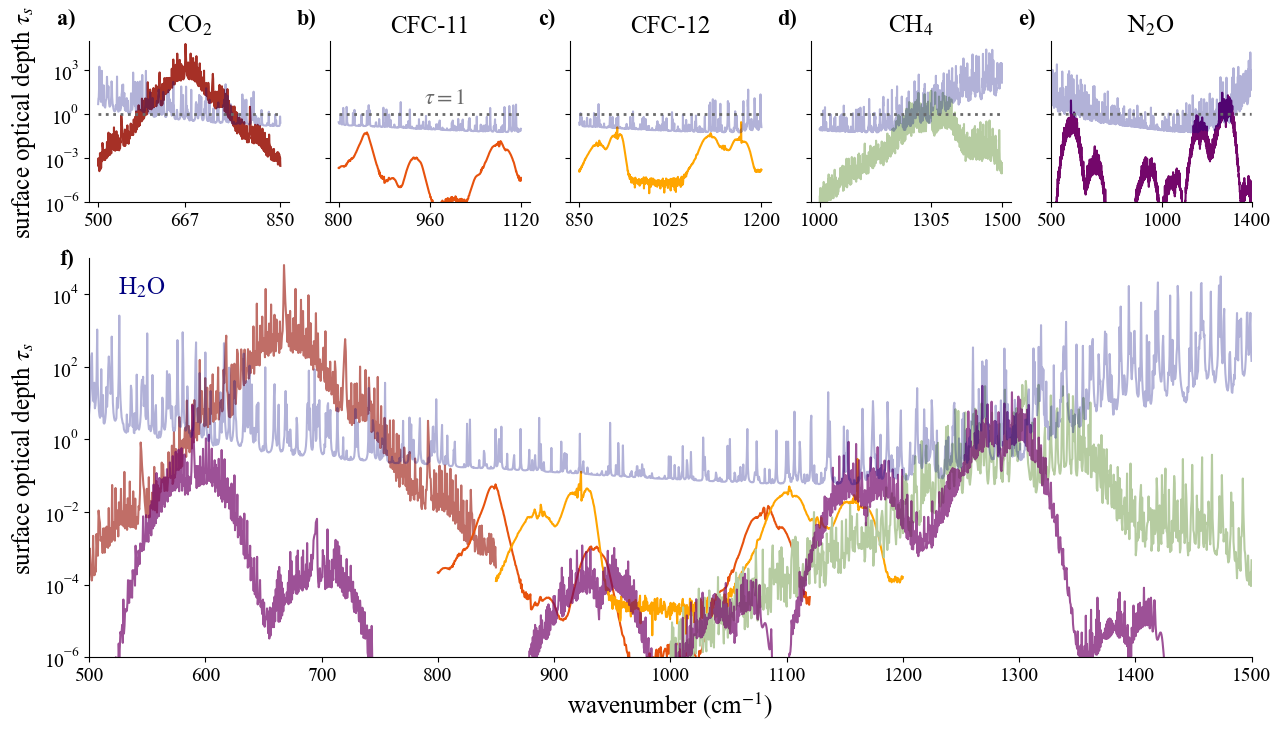

In [13]:
fig, axes = plt.subplots(figsize = (15, 8), layout = 'compressed', sharey = True)
fig.clf()
gs = gridspec.GridSpec(2, 5, height_ratios=[0.25, 0.62])


h2o_color ='navy'
#axes[2].set_xlabel("wavenumber $\\nu$ (cm$^{-1}$)")
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[0, 2])
ax3 = fig.add_subplot(gs[0, 3])
ax4 = fig.add_subplot(gs[0, 4])
ax5 = fig.add_subplot(gs[1, :])

ax0.set_ylabel("surface optical depth $\\tau_s$")
ax5.set_ylabel("surface optical depth $\\tau_s$")


ax0.semilogy(co2_band, 2*(420e-6)*co2_c_tau.T[0, :], color = co2_color)
ax0.semilogy(co2_band, h2o_tau_co2_cumulative.T[0, :], color = h2o_color, alpha = 0.3)
ax0.semilogy(co2_band, np.ones(len(co2_band)), linestyle = 'dotted', color = 'dimgrey', linewidth = 2)
ax0.set_title("CO$_2$")
ax0.set_xticks([np.min(co2_band), 667, np.max(co2_band)])

ax1.semilogy(cfc11_band, 2*(cfc11_vmr)*cfc11_c_tau.T[0, :], color = cfc11_color)
ax1.semilogy(cfc11_band, h2o_tau_cfc11_cumulative.T[0, :], color = h2o_color, alpha = 0.3)
ax1.semilogy(cfc11_band, np.ones(len(cfc11_band)), linestyle = 'dotted', color = 'dimgrey', linewidth = 2)
ax1.set_xticks([np.min(cfc11_band), np.mean(cfc11_band), np.max(cfc11_band)])
ax1.set_title("CFC-11")

ax2.semilogy(cfc12_band, 2*(cfc12_vmr)*cfc12_c_tau.T[0, :], color = cfc12_color)
ax2.semilogy(cfc12_band, h2o_tau_cfc12_cumulative.T[0, :], color = h2o_color, alpha = 0.3)
ax2.semilogy(cfc12_band, np.ones(len(cfc12_band)), linestyle = 'dotted', color = 'dimgrey', linewidth = 2)
ax2.set_xticks([np.min(cfc12_band), np.mean(cfc12_band), np.max(cfc12_band)])
ax2.set_title("CFC-12")

ax3.semilogy(ch4_band, 2*(ch4_vmr)*ch4_cum_tau.T[0, :], color = band_color)
ax3.semilogy(ch4_band, h2o_tau_ch4_cumulative.T[0, :], color = h2o_color, alpha = 0.3)
ax3.semilogy(ch4_band, np.ones(len(ch4_band)), linestyle = 'dotted', color = 'dimgrey', linewidth = 2)
ax3.set_xticks([np.min(ch4_band), 1305, np.max(ch4_band)])
ax3.set_title("CH$_4$")

ax4.semilogy(n2o_band, 2*(n2o_vmr)*n2o_c_tau.T[0, :], color = band3_color)
ax4.semilogy(n2o_band, h2o_tau_n2o_cumulative.T[0, :], color = h2o_color, alpha = 0.3)
ax4.semilogy(n2o_band, np.ones(len(n2o_band)), linestyle = 'dotted', color = 'dimgrey', linewidth = 2)
ax4.set_xticks([500, 1000, 1400])
ax4.set_xlim([500, 1400])
ax4.set_title("N$_2$O")


ax0.set_ylim([10**-6, 10**5])
ax1.set_ylim([10**-6, 10**5])
ax2.set_ylim([10**-6, 10**5])
ax3.set_ylim([10**-6, 10**5])
ax4.set_ylim([10**-6, 10**5])

ax1.text(950, 5, '$\\tau = 1$', fontsize = 16, color = 'dimgray')

ax5.set_ylim([10**-6, 10**5])

ax5.text(525, 10**4, 'H$_2$O', fontsize = 18, color = h2o_color)

ax5.semilogy(co2_band, 2*(420e-6)*co2_c_tau.T[0, :], color = co2_color, alpha = 0.7)

ax5.semilogy(cfc11_band, 2*(cfc11_vmr)*cfc11_c_tau.T[0, :], color = cfc11_color)
ax5.semilogy(cfc12_band, 2*(cfc12_vmr)*cfc12_c_tau.T[0, :], color = cfc12_color)
ax5.semilogy(ch4_band, 2*(ch4_vmr)*ch4_cum_tau.T[0, :], color = band_color)
ax5.semilogy(n2o_band, 2*(n2o_vmr)*n2o_c_tau.T[0, :], color = band3_color, alpha = 0.7)
ax5.semilogy(n2o_band, h2o_tau_n2o_cumulative.T[0, :], color = h2o_color, alpha = 0.3)

ax5.set_xlim([500, 1500])
ax5.set_xticks(np.linspace(500, 1500, 11))
sns.despine()

ax1.set_yticklabels([])
ax2.set_yticklabels([])
ax3.set_yticklabels([])
ax4.set_yticklabels([])

ax5.set_xlabel("wavenumber (cm$^{-1}$)")

fig.text(0.11, 0.9, 'a)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.27, 0.9, 'b)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.43, 0.9, 'c)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.59, 0.9, 'd)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.75, 0.9, 'e)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.11, 0.6, 'f)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')

plt.savefig("figures/tau_spectrum.png", bbox_inches = 'tight', dpi = 600)
plt.show()


### Figure 2
Weighting function schematic

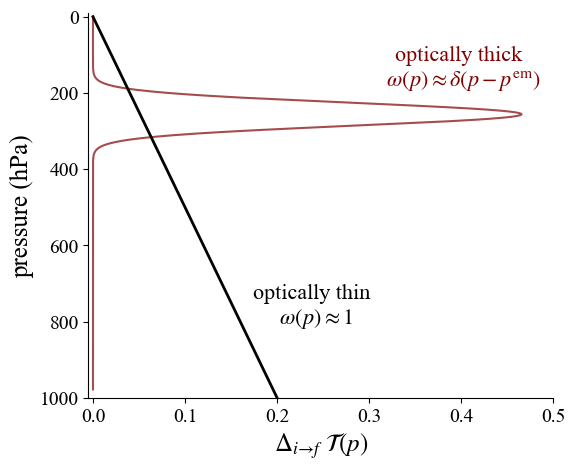

In [13]:
plev_ref, phlev_ref = konrad.utils.get_pressure_grids(1000e2, 1, 129)


fig, ax = plt.subplots(1, 1, figsize = (6, 5))

# dirac delta example
ax.plot(3500*stats.norm.pdf(np.linspace(plev_ref[0], plev_ref[-1], 1000), plev_ref[25], 3000), (np.linspace(plev_ref[0], plev_ref[-1], 1000))/100, color = 'maroon', alpha = 0.7)

# linear example
ax.plot(np.linspace(0, 0.2), np.linspace(0, 1000), color = 'black', linewidth = 2)

# set labels
ax.set_xlabel("$\\Delta_{i \\to f}$ $\mathcal{T}(p)$")
ax.set_xlim([-0.005, 0.5])

ax.text(0.4, 75, "optically thick \n $\omega(p) \\approx \delta(p - p^{\mathrm{em}})$", color = 'maroon', fontsize = 16, ha = 'center', va = 'top')

ax.text(0.24, 700, "optically thin \n $\omega(p) \\approx 1$", color = 'black', fontsize = 16, ha = 'center', va = 'top')

sns.despine()
ax.set_ylim([1000, -10])
ax.set_yticks([1000, 800, 600, 400, 200, 0], ['1000', '800', '600', '400', '200', '0'])
ax.set_ylabel("pressure (hPa)")

plt.savefig("figures/omega_simple.pdf", bbox_inches = 'tight', dpi = 600)
plt.show()

### Figure 3
Monochromatic forcing.

In [14]:
# calculate OLR with own Schwarzschild eqn. solver
cfc12_present_OLR = flux_up_profile(atmosphere.data_vars["T"][1][0], plev, 0*2*cfc12_vmr*cfc12_c_tau.T, cfc12_band)[-1] 
cfc12_4x_OLR = flux_up_profile(atmosphere.data_vars["T"][1][0], plev, 2*cfc12_vmr*cfc12_c_tau.T, cfc12_band)[-1]
cfc12_forcing = cfc12_present_OLR - cfc12_4x_OLR

cfc11_present_OLR = flux_up_profile(atmosphere.data_vars["T"][1][0], plev, 0*2*cfc11_vmr*cfc11_c_tau.T, cfc11_band)[-1] 
cfc11_4x_OLR = flux_up_profile(atmosphere.data_vars["T"][1][0], plev, 2*cfc11_vmr*cfc11_c_tau.T, cfc11_band)[-1]
cfc11_forcing = cfc11_present_OLR - cfc11_4x_OLR

# multiply concentration by 4
n = 4
co2_present_OLR = flux_up_profile(atmosphere.data_vars["T"][1][0], plev, 2*(5*10**-10)*co2_c_tau.T, co2_band)[-1] 
co2_4x_OLR = flux_up_profile(atmosphere.data_vars["T"][1][0], plev, n*2*(5*10**-10)*co2_c_tau.T, co2_band)[-1]
co2_forcing = co2_present_OLR - co2_4x_OLR

## model calculations
co2_model = np.empty(len(co2_band))
cfc12_model = np.empty(len(cfc12_band))
cfc11_model = np.empty(len(cfc11_band))

# loop through each band
for nu_idx, nu in enumerate(co2_band):
    co2_model[nu_idx] = thin_model_monochromatic(atmosphere.data_vars["T"][1][0], plev, nu, (2*(5*10**-10)*co2_c_tau.T)[:, nu_idx], (4*2*(5*10**-10)*co2_c_tau.T)[:, nu_idx])
    
for nu_idx, nu in enumerate(cfc12_band):
    cfc12_model[nu_idx] = thin_model_monochromatic(atmosphere.data_vars["T"][1][0], plev, nu,(0*cfc12_c_tau.T)[:, nu_idx], (2*cfc12_vmr*cfc12_c_tau.T)[:, nu_idx])
    
for nu_idx, nu in enumerate(cfc11_band):
    cfc11_model[nu_idx] = thin_model_monochromatic(atmosphere.data_vars["T"][1][0], plev, nu, (0*cfc11_c_tau.T)[:, nu_idx], (2*cfc11_vmr*cfc11_c_tau.T)[:, nu_idx])

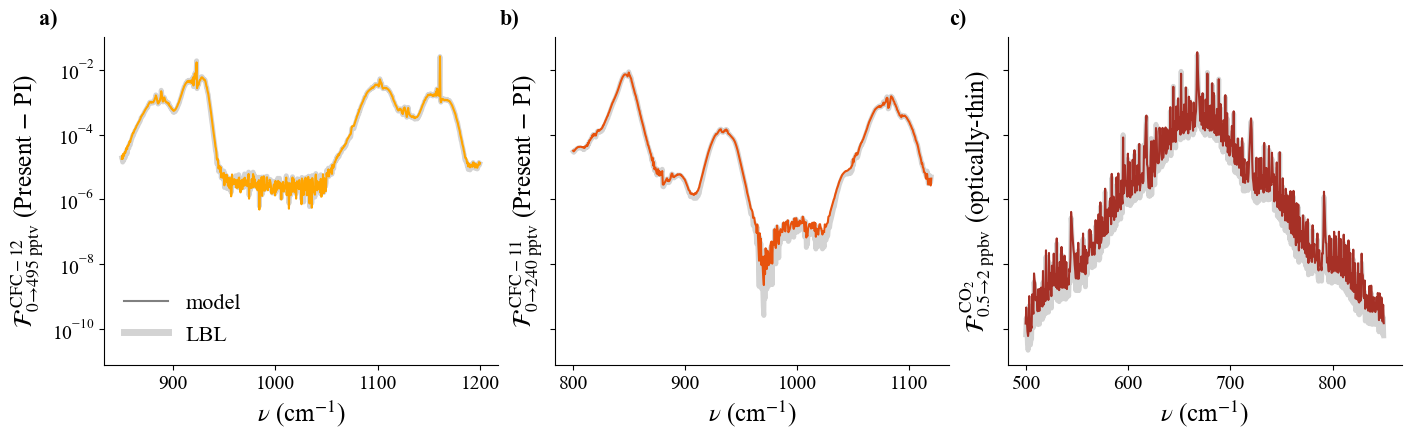

In [15]:
fig, axes = plt.subplots(1, 3, figsize = (14, 4), layout = 'compressed', sharey = True)
ref_color = 'lightgrey'

ax1, ax2, ax3 = axes[0], axes[1], axes[2]

# cfc-12
ax1.semilogy(cfc12_band, cfc12_forcing, color = ref_color, linewidth = 3.5)
ax1.semilogy(cfc12_band, cfc12_model, linestyle = 'solid', color = cfc12_color, linewidth = 1.5)
ax1.set_ylabel("$\mathcal{F}^{~\mathrm{CFC-12}}_{0 \\to 495~ \mathrm{pptv}}$ (Present $-$ PI)")
ax1.set_xlabel("$\\nu$ (cm$^{-1}$)")

# cfc-11
ax2.semilogy(cfc11_band, cfc11_forcing, color = ref_color, linewidth = 3.5)
ax2.semilogy(cfc11_band, cfc11_model, linestyle = 'solid', color = cfc11_color, linewidth = 1.5)
ax2.set_ylabel("$\mathcal{F}^{~\mathrm{CFC-11}}_{0 \\to 240 ~\mathrm{pptv}}$ (Present $-$ PI)")
ax2.set_xlabel("$\\nu$ (cm$^{-1}$)")

# co2
ax3.semilogy(co2_band, co2_forcing, color = ref_color, linewidth = 3.5)
ax3.semilogy(co2_band, co2_model, linestyle = 'solid', color = co2_color, linewidth = 1.5)
ax3.set_ylabel("$\mathcal{F}^{~\mathrm{CO_2}}_{0.5 \\to 2 ~\mathrm{ppbv}}$ (optically-thin)")
ax3.set_xlabel("$\\nu$ (cm$^{-1}$)")

ax1.semilogy(1000, 0, color = 'grey', label = 'model')
ax1.semilogy(1000, 0, color = ref_color, linewidth = 5, label = 'LBL')
ax1.legend(frameon = False)

# labels
sns.despine()
fig.text(0.03, 1.02, 'a)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.36, 1.02, 'b)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.68, 1.02, 'c)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')

plt.savefig("figures/validation_thin.pdf", bbox_inches = 'tight', dpi = 600)

plt.show()

### Figure 4
Thin IRF is linear in $\tau$.

In [16]:
### Line-by-line thin gas forcing

# concentrations (ppmv)
c = np.array([1, 2, 4, 6, 8, 10, 12, 14, 16])*10**(-10)

cfc12_step = np.zeros((len(c)))
cfc11_step = np.zeros((len(c)))
co2_step = np.zeros((len(c)))

# initial OLR (zero)
cfc12_zero_OLR = np.trapz(flux_up_profile(atmosphere.data_vars["T"][1][0], plev, 0*2*cfc12_vmr*cfc12_c_tau.T, cfc12_band)[-1], cfc12_band) 
cfc11_zero_OLR = np.trapz(flux_up_profile(atmosphere.data_vars["T"][1][0], plev, 0*2*cfc11_vmr*cfc11_c_tau.T, cfc11_band)[-1], cfc11_band)
co2_zero_OLR = np.trapz(flux_up_profile(atmosphere.data_vars["T"][1][0], plev, 0*2*(5*10**-10)*co2_c_tau.T, co2_band)[-1], co2_band)

# step through multiples
for c_idx, conc in enumerate(c):

    # compute and integrate perturbed OLR
    cfc12_temp_OLR = np.trapz(flux_up_profile(atmosphere.data_vars["T"][1][0], plev, 2*conc*cfc12_c_tau.T, cfc12_band)[-1], cfc12_band) 
    cfc11_temp_OLR = np.trapz(flux_up_profile(atmosphere.data_vars["T"][1][0], plev, 2*conc*cfc11_c_tau.T, cfc11_band)[-1], cfc11_band)
    co2_temp_OLR = np.trapz(flux_up_profile(atmosphere.data_vars["T"][1][0], plev, 2*conc*co2_c_tau.T, co2_band)[-1], co2_band)
    
    # subtract from initial condition
    cfc12_step[c_idx] = cfc12_zero_OLR - cfc12_temp_OLR
    cfc11_step[c_idx] = cfc11_zero_OLR - cfc11_temp_OLR
    co2_step[c_idx] = co2_zero_OLR - co2_temp_OLR

cfc12_present_OLR = np.trapz(flux_up_profile(atmosphere.data_vars["T"][1][0], plev, 2*cfc12_vmr*cfc12_c_tau.T, cfc12_band)[-1], cfc12_band) 
cfc11_present_OLR = np.trapz(flux_up_profile(atmosphere.data_vars["T"][1][0], plev, 2*cfc11_vmr*cfc11_c_tau.T, cfc11_band)[-1], cfc11_band)

cfc12_present_forcing = cfc12_zero_OLR - cfc12_present_OLR
cfc11_present_forcing = cfc11_zero_OLR - cfc11_present_OLR

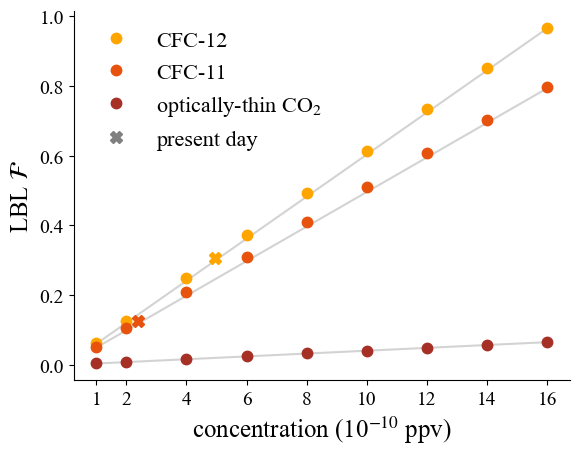

In [17]:
### plot forcing

# linear fit
plt.plot(c*10**10, c*10**10*(cfc12_step[-1] - cfc12_step[0])/((c[-1]*10**10 - c[0]*10**10)), color = 'lightgrey')
plt.plot(c*10**10, c*10**10*(cfc11_step[-1] - cfc11_step[0])/((c[-1]*10**10 - c[0]*10**10)), color = 'lightgrey')
plt.plot(c*10**10, c*10**10*(co2_step[-1] - co2_step[0])/((c[-1]*10**10 - c[0]*10**10)), color = 'lightgrey')

# plot forcing
plt.plot(c*10**10, cfc12_step, '.', markersize = 15,  color = cfc12_color, label = 'CFC-12')
plt.plot(cfc12_vmr*10**10, cfc12_present_forcing, 'X', markersize = 8, color = cfc12_color)
plt.plot(cfc11_vmr*10**10, cfc11_present_forcing, 'X', markersize = 8, color = cfc11_color)
plt.plot(c*10**10, cfc11_step, '.', markersize = 15, color = cfc11_color, label = 'CFC-11')
plt.plot(c*10**10, co2_step, '.', markersize = 15, color = co2_color, label = 'optically-thin CO$_2$')
plt.plot([], [], 'X', markersize = 8, color = 'grey', label = 'present day')

# ticks, labels
plt.xticks(c*10**10)
plt.legend(frameon = False)
plt.ylabel("LBL $\mathcal{F}$")
plt.xlabel("concentration (10$^{-10}$ ppv)")
sns.despine()

plt.savefig("figures/linear_tau.pdf", bbox_inches = 'tight', dpi = 600)
plt.show()

### Figure 5
ERA5 temperature/RH, and CFC12 forcing maps.

In [13]:
era = xr.open_dataset('/data/pc2943/ERA5_March1981_monthlymean.nc', engine = "netcdf4")
lats = era.latitude.data[::72]# merged_data.latitude.data
longs = np.array([0.,  36.25,  72.5 , 108.75, 145.  , 181.25, 217.5 , 253.75,
       290.  , 326.25, 3.5975e+02]) #merged_data.longitude.data

mean_rh = np.empty((len(lats), len(longs)))
surfaceT = np.empty((len(lats), len(longs)))

# loop through each lat and long, compute model value
for lat_idx in range(len(lats)):
    for long_idx in range(len(longs)):

        if lat_idx == 0 or lat_idx == len(lats) - 1:
            if long_idx == 0:
                profile_data = xr.open_dataset('/data/pc2943/era5_present_tau_' + str(lat_idx) + '_' + str(long_idx) + '.h5', engine = "netcdf4")
                profile_data_ch4 = xr.open_dataset('/data/pc2943/era5_ch4_' + str(lat_idx) + '_' + str(long_idx) + '.h5', engine = "netcdf4")

        
        else:
            profile_data = xr.open_dataset('/data/pc2943/era5_present_tau_' + str(lat_idx) + '_' + str(long_idx) + '.h5', engine = "netcdf4")
            profile_data_ch4 = xr.open_dataset('/data/pc2943/era5_ch4_' + str(lat_idx) + '_' + str(long_idx) + '.h5', engine = "netcdf4")

  
        
        temperature = profile_data.t.data[0, 0]
        pressure =  profile_data.level.data

        surfaceT[lat_idx, long_idx] = temperature[0]
        T_Trop = np.min(temperature)
        Trop_idx = np.where(temperature == T_Trop)[0][0]
        z = (16000 * (5.0 - np.log10(pressure[:Trop_idx])))
        mean_rh[lat_idx, long_idx] = np.trapz(profile_data.rh[0, 0, :Trop_idx], pressure[:Trop_idx])/np.trapz(np.ones(len(pressure[:Trop_idx])), pressure[:Trop_idx])



In [14]:
band_average_cfc12_forcing_dry = np.empty((len(lats), len(longs)))
lbl_cfc12 = np.empty((len(lats), len(longs)))
lbl_ch4_present = np.empty((len(lats), len(longs)))
lbl_ch4_4x = np.empty((len(lats), len(longs)))

lapses = np.empty((len(lats), len(longs)))
surfaceT = np.empty((len(lats), len(longs)))

# loop through each lat and long, compute model value
for lat_idx in range(len(lats)):
    for long_idx in range(len(longs)):

        if lat_idx == 0 or lat_idx == len(lats) - 1:
            if long_idx == 0:
                profile_data = xr.open_dataset('/data/pc2943/era5_present_tau_' + str(lat_idx) + '_' + str(long_idx) + '.h5', engine = "netcdf4")
                profile_data_ch4 = xr.open_dataset('/data/pc2943/era5_ch4_' + str(lat_idx) + '_' + str(long_idx) + '.h5', engine = "netcdf4")

        
        else:
            profile_data = xr.open_dataset('/data/pc2943/era5_present_tau_' + str(lat_idx) + '_' + str(long_idx) + '.h5', engine = "netcdf4")
            profile_data_ch4 = xr.open_dataset('/data/pc2943/era5_ch4_' + str(lat_idx) + '_' + str(long_idx) + '.h5', engine = "netcdf4")

  
        
        temperature = profile_data.t.data[0, 0]
        pressure =  profile_data.level.data

        surfaceT[lat_idx, long_idx] = temperature[0]
        T_Trop = np.min(temperature)
        Trop_idx = np.where(temperature == T_Trop)[0][0]
        z = (16000 * (5.0 - np.log10(pressure[:Trop_idx])))
        lapses[lat_idx, long_idx] = np.trapz(temperature[:Trop_idx], pressure[:Trop_idx])/np.trapz(np.ones(len(pressure[:Trop_idx])), pressure[:Trop_idx])

        q = mpcalc.saturation_mixing_ratio(pressure[0] * units('Pa'), temperature[0] * units('K')).to('kg/kg')

        mvt_tau = tau_nu(pressure, 198, cfc12_mmr)* np.ones((len(profile_data.wavenumber.data), len(pressure)))

        band_average_cfc12_forcing_dry[lat_idx, long_idx] = thin_model_linear_band_average_Bbar(temperature, pressure, profile_data.wavenumber.data, 0*mvt_tau, mvt_tau, 1025, np.zeros(mvt_tau.shape), 1)

        lbl_cfc12[lat_idx, long_idx] = np.trapz(profile_data.forcing_cfc12.data, profile_data.wavenumber.data)
        lbl_ch4_present[lat_idx, long_idx] = np.trapz(profile_data_ch4.forcing_ch4_PI.data, profile_data_ch4.wavenumber.data)
        lbl_ch4_4x[lat_idx, long_idx] = np.trapz(profile_data_ch4.forcing_ch4_4x.data, profile_data_ch4.wavenumber.data)

In [15]:
### Calculations with H2O
#H2O parameters
plev_ref, phlev_ref = konrad.utils.get_pressure_grids(1000e2, 1, 129)

rh_ref = 0.75
T_ref_cont = 275
T_ref_line = 245
p_ref = (plev_ref)[19]

# idealized H2O coefficients
k_self_idealized = np.ones(len(profile_data.wavenumber.data)) * 0.006
k_line_idealized = k(0.6, 1200, 7, profile_data.wavenumber.data)

band_average_cfc12_forcing_h2o = np.empty((len(lats), len(longs)))
lbl_cfc12_w_h2o = np.empty((len(lats), len(longs)))

# loop through ERA5 atmospheres including H2O
for lat_idx in range(len(lats)):
    for long_idx in range(len(longs)):

        if lat_idx == 0 or lat_idx == len(lats) - 1:
            if long_idx == 0:
                profile_data = xr.open_dataset('/data/pc2943/era5_present_tau_' + str(lat_idx) + '_' + str(long_idx) + '.h5', engine = "netcdf4")
        
        else:
            profile_data = xr.open_dataset('/data/pc2943/era5_present_tau_' + str(lat_idx) + '_' + str(long_idx) + '.h5', engine = "netcdf4")

        temperature = profile_data.t.data[0, 0]
        pressure =  profile_data.level.data
        q = mpcalc.saturation_mixing_ratio(pressure[0] * units('Pa'), temperature[0] * units('K')).to('kg/kg')
        rh = profile_data.rh.data/100

        line_idealized_tau = np.empty((len(profile_data.wavenumber.data), len(pressure)))
        cont_idealized_tau = np.empty((len(profile_data.wavenumber.data), len(pressure)))
        
        for nu_idx, nu in enumerate(profile_data.wavenumber.data):
            # defined in H2O schematic block
            line_idealized_tau[nu_idx, :] = line_tau(k_line_idealized[nu_idx], pressure, p_ref, temperature, rh)
            cont_idealized_tau[nu_idx, :] = cont_tau(k_self_idealized[nu_idx], temperature, T_ref_cont, rh, rh_ref)

        mvt_tau = tau_nu(pressure, 198, cfc12_mmr)* np.ones((len(profile_data.wavenumber.data), len(pressure)))
        band_average_cfc12_forcing_h2o[lat_idx, long_idx] = thin_model_linear_band_average_Bbar(temperature, pressure, profile_data.wavenumber.data, 0*mvt_tau, mvt_tau, 1025, (line_idealized_tau + cont_idealized_tau), 0.6)

        lbl_cfc12_w_h2o[lat_idx, long_idx] = np.trapz(profile_data.forcing_w_h2o.data, profile_data.wavenumber.data)


In [16]:
## Calculate global mean values
era5_areas = area_grid(lats, longs)
lbl_cfc12_global_mean = np.sum(lbl_cfc12*era5_areas / np.sum(era5_areas))
lbl_cfc12_w_h2o_global_mean = np.sum(lbl_cfc12_w_h2o*era5_areas / np.sum(era5_areas))
theory_cfc12_global_mean = np.sum(band_average_cfc12_forcing_dry*era5_areas / np.sum(era5_areas))
theory_cfc12_w_h2o_global_mean = np.sum(band_average_cfc12_forcing_h2o*era5_areas / np.sum(era5_areas))

/tmp/ipykernel_2053196/2195573619.py:10: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = fig.colorbar(plt.cm.ScalarMappable(norm=colors.Normalize(vmin=230, vmax=310), cmap='RdYlBu_r'), cax = None, ticks = [230, 250, 270, 290, 310], location = 'bottom')
/tmp/ipykernel_2053196/2195573619.py:20: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = fig.colorbar(plt.cm.ScalarMappable(norm=colors.Normalize(vmin=20, vmax=80), cmap='Blues'), cax = None, ticks = [20, 40, 60, 80], location = 'bottom')
/tmp/ipykernel_2053196/2195573

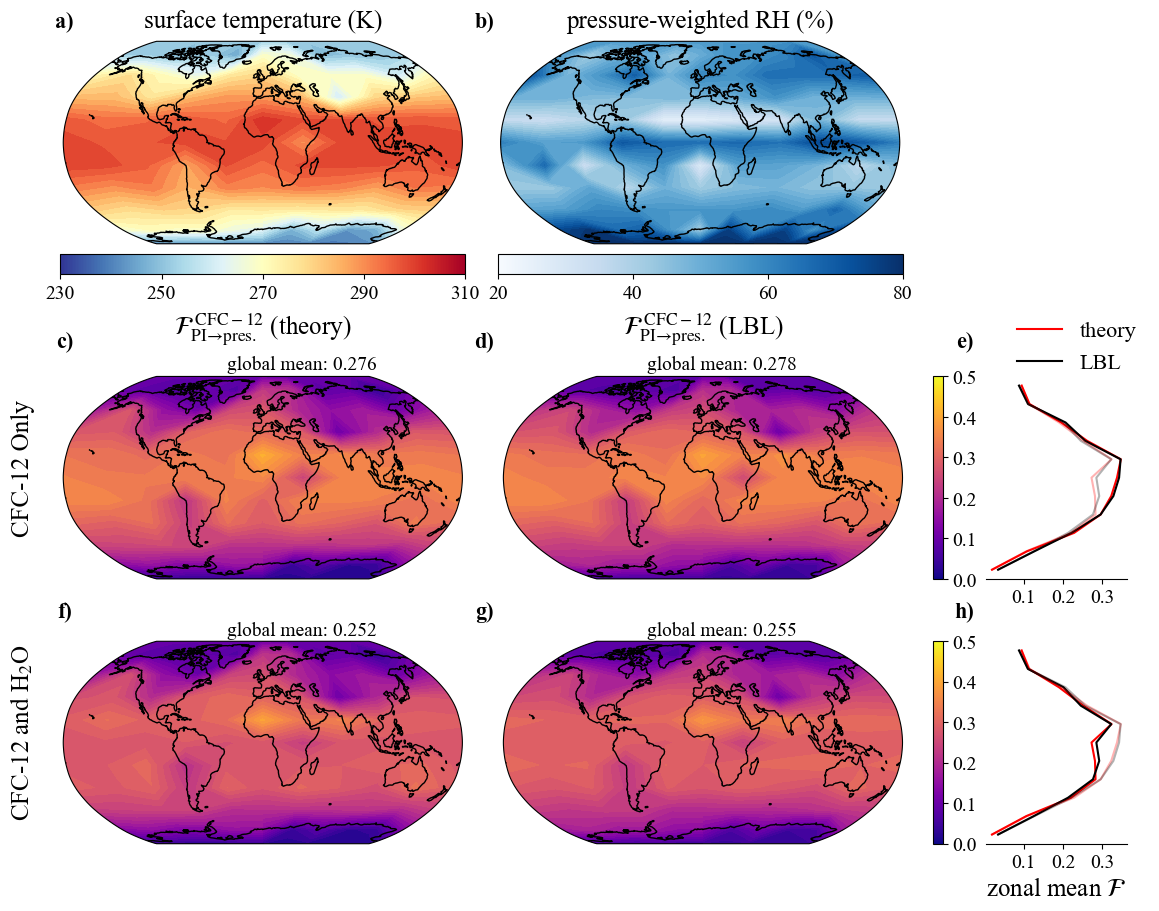

In [37]:
### Plot CFC-12 only map

fig = plt.figure(figsize = (12, 9),layout = 'compressed')
gs = fig.add_gridspec(3, 3, width_ratios=[1,1,0.35], height_ratios = [1, 1, 1])

# temperature
ax1 = fig.add_subplot(gs[0, 0], projection = ccrs.Robinson())
c1 = ax1.contourf(longs, lats, surfaceT, 30, 
                  transform = ccrs.PlateCarree(), cmap = 'RdYlBu_r', norm=colors.Normalize(vmin=230, vmax=310))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=colors.Normalize(vmin=230, vmax=310), cmap='RdYlBu_r'), cax = None, ticks = [230, 250, 270, 290, 310], location = 'bottom')

ax1.coastlines()
ax1.set_title("surface temperature (K)", pad = 10)

# rh
ax2 = fig.add_subplot(gs[0, 1], projection = ccrs.Robinson())
c2 = ax2.contourf(longs, lats, 
                  mean_rh,
                  30, transform = ccrs.PlateCarree(), cmap = 'Blues', norm=colors.Normalize(vmin=20, vmax=80))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=colors.Normalize(vmin=20, vmax=80), cmap='Blues'), cax = None, ticks = [20, 40, 60, 80], location = 'bottom')

ax2.coastlines()
ax2.set_title("pressure-weighted RH (%)", pad = 10)

# model values on subplot 1
ax1 = fig.add_subplot(gs[1, 0], projection = ccrs.Robinson())
c1 = ax1.contourf(longs, lats, band_average_cfc12_forcing_dry, 30, 
                  transform = ccrs.PlateCarree(), cmap = 'plasma', norm=colors.Normalize(vmin=0, vmax=0.5))
ax1.coastlines()
ax1.set_title("$\mathcal{F}^{~\mathrm{CFC-12}}_{\mathrm{PI}\\to\mathrm{pres.}}$ (theory)\n")
ax1.text(-0.07, 0.55, 'CFC-12 Only', va='bottom', ha='center',
        rotation='vertical', rotation_mode='anchor',
        transform=ax1.transAxes, fontsize = 18)


# LBL values on subplot 2
ax2 = fig.add_subplot(gs[1, 1], projection = ccrs.Robinson())
c2 = ax2.contourf(longs, lats, 
                  lbl_cfc12,
                  30, transform = ccrs.PlateCarree(), cmap = 'plasma', norm=colors.Normalize(vmin=0, vmax=0.5))
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=colors.Normalize(vmin=0, vmax=0.5), cmap='plasma'), cax = None, ticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5])

ax2.coastlines()
ax2.set_title("$\mathcal{F}^{~\mathrm{CFC-12}}_{\mathrm{PI}\\to\mathrm{pres.}}$ (LBL)\n")

# zonal means on axis 3
ax3 = fig.add_subplot(gs[1, 2])
ax3.plot(np.mean(band_average_cfc12_forcing_dry, axis = -1), lats, color = 'red', label = 'theory')
ax3.plot(np.mean(lbl_cfc12, axis = -1), lats, color = 'black', label = 'LBL')
ax3.plot(np.mean(band_average_cfc12_forcing_h2o, axis = -1), lats, color = 'red', alpha = 0.3)
ax3.plot(np.mean(lbl_cfc12_w_h2o, axis = -1), lats, color = 'black', alpha = 0.3)
sns.despine(ax = ax3, left = True)
ax3.yaxis.set_visible(False)
fig.legend(frameon = False, loc=(0.87,0.58))


### Plot maps with H2O overlap

# plot model results on axis 1
ax4 = fig.add_subplot(gs[2, 0], projection = ccrs.Robinson())
c1 = ax4.contourf(longs, lats, band_average_cfc12_forcing_h2o, 30, 
                  transform = ccrs.PlateCarree(), cmap = 'plasma', norm=colors.Normalize(vmin=0, vmax=0.5))
ax4.coastlines()
ax4.text(-0.07, 0.55, 'CFC-12 and H$_2$O', va='bottom', ha='center',
        rotation='vertical', rotation_mode='anchor',
        transform=ax4.transAxes, fontsize = 18)

# plot LBL results on axis 2
ax5 = fig.add_subplot(gs[2, 1], projection = ccrs.Robinson())
c2 = ax5.contourf(longs, lats, 
                  lbl_cfc12_w_h2o,
                  30, transform = ccrs.PlateCarree(), cmap = 'plasma', norm=colors.Normalize(vmin=0, vmax=0.5))

cbar = fig.colorbar(plt.cm.ScalarMappable(norm=colors.Normalize(vmin=0, vmax=0.5), cmap='plasma'), cax = None, ticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5])

ax5.coastlines()
ax5.set_title(" ")

# plot zonal mean on axis 3
ax6 = fig.add_subplot(gs[2, 2], sharex = ax3)
ax6.plot(np.mean(band_average_cfc12_forcing_h2o, axis = -1), lats, color = 'red')
ax6.plot(np.mean(lbl_cfc12_w_h2o, axis = -1), lats, color = 'black')
ax6.plot(np.mean(band_average_cfc12_forcing_dry, axis = -1), lats, color = 'red', alpha = 0.3)
ax6.plot(np.mean(lbl_cfc12, axis = -1), lats, color = 'black', alpha = 0.3)
ax6.set_xlabel("zonal mean $\mathcal{F}$")
sns.despine(ax = ax6, left = True)
ax6.yaxis.set_visible(False)


# labels
fig.text(0.08, 0.975, 'a)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.43, 0.975, 'b)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.08, 0.62, 'c)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.43, 0.62, 'd)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.83, 0.62, 'e)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.08, 0.32, 'f)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.43, 0.32, 'g)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.83, 0.32, 'h)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')


fig.text(0.34, 0.595, ("global mean: %.3f" %(theory_cfc12_global_mean)), color = 'black', fontsize = 14, ha = 'right')
fig.text(0.69, 0.595, ("global mean: %.3f" %(lbl_cfc12_global_mean)), color = 'black', fontsize = 14, ha = 'right')
fig.text(0.34, 0.3, ("global mean: %.3f" %(theory_cfc12_w_h2o_global_mean)), color = 'black', fontsize = 14, ha = 'right')
fig.text(0.69, 0.30, ("global mean: %.3f" %(lbl_cfc12_w_h2o_global_mean)), color = 'black', fontsize = 14, ha = 'right')

plt.savefig("figures/cfc12_maps_and_climatology.png", bbox_inches = 'tight', dpi = 300)

plt.show()


### Figure 6
RH/T phase space

In [23]:
### Compute reference data
# set range of surface temperatures and relative humidity
range_Ts = np.array([260, 270, 280, 290, 300, 310])
range_rh = np.array([0, 0.25, 0.5, 0.75, 1])[::-1]
t_colors = cc.CET_L18[60:][::25]
rh_colors = cc.kbc[::55]

ref_forcing_raster = np.zeros((len(range_Ts), len(range_rh)))
model_forcing_raster = np.zeros((len(range_Ts), len(range_rh)))

# loop through T_s and rh
for T_idx, T_s in enumerate(range_Ts):
    for rh_idx, rh in enumerate(range_rh):
        plev, phlev = konrad.utils.get_pressure_grids(1000e2, 1, 128)
        atmosphere = konrad.atmosphere.Atmosphere(phlev)
        T, h2o_vmr, q = create_profile_moist(T_s, rh, plev)
        atmosphere["H2O"][:] = h2o_vmr
        atmosphere["T"][:] = T
        atmosphere["CFC12"][:] = 0
        arts_atmosphere = atmosphere.to_atm_fields_compact()
        # CFC-12 with moist adiabatic H2O at pre-industrial concentrations
        # (LBL calculation)
        presentOLR, _, _, _, present_tau, _ = calc_lbl_rt(arts_atmosphere, species = ["H2O", "H2O-SelfContCKDMT350", "CFC12-XFIT"], w_grid = cfc12_band)

        # CFC-12 with moist adiabatic H2O at present day concentrations
        # (LBL calculation)
        atmosphere["CFC12"][:] = 4.95e-10
        arts_atmosphere = atmosphere.to_atm_fields_compact()
        forcedOLR, _, _, _, forced_tau, _ = calc_lbl_rt(arts_atmosphere, species = ["H2O", "H2O-SelfContCKDMT350", "CFC12-XFIT"], w_grid = cfc12_band)

        # cumulative optical depth
        present_tau_c = np.cumsum(present_tau[:, ::-1], axis = 1)[:, ::-1]
        forced_tau_c = np.cumsum(forced_tau[:, ::-1], axis = 1)[:, ::-1]

        # solve Schwarzschild eqn.
        calc_OLR_present = flux_up_profile(T.magnitude, plev, 2*present_tau_c.T, cfc12_band)[-1]
        calc_OLR_forced = flux_up_profile(T.magnitude, plev, 2*forced_tau_c.T, cfc12_band)[-1]

        # integrate and record
        ref_forcing_raster[T_idx, rh_idx] = np.trapz(calc_OLR_present - calc_OLR_forced, cfc12_band)
        


# run idealized model
for T_idx, T_s in enumerate(range_Ts):
    for rh_idx, rh in enumerate(range_rh):
        # set up atmosphere
        plev, phlev = konrad.utils.get_pressure_grids(1000e2, 1, 128)
        atmosphere = konrad.atmosphere.Atmosphere(phlev)
        T, h2o_vmr, q = create_profile_moist(T_s, rh, plev)
        atmosphere["H2O"][:] = h2o_vmr
        atmosphere["T"][:] = T 

        # calculate idealized H2O optical depth
        line_idealized_tau = np.empty((len(cfc12_band), len(plev)))
        cont_idealized_tau = np.empty((len(cfc12_band), len(plev)))
        
        for nu_idx, nu in enumerate(cfc12_band):
            line_idealized_tau[nu_idx, :] = line_tau(k_line_idealized[nu_idx], plev, p_ref, T.magnitude, rh)
            cont_idealized_tau[nu_idx, :] = cont_tau(k_self_idealized[nu_idx], T.magnitude, T_ref_cont, rh, rh_ref)

        # calculate Eqn. 13
        mvt_tau = tau_nu(plev, 198, cfc12_mmr)* np.ones((len(cfc12_band), len(plev)))     
        model_forcing_raster[T_idx, rh_idx] = thin_model_linear_band_average(T.magnitude, plev, cfc12_band, 0*mvt_tau, mvt_tau, 1025, (line_idealized_tau + cont_idealized_tau), 0.6, q, 4)



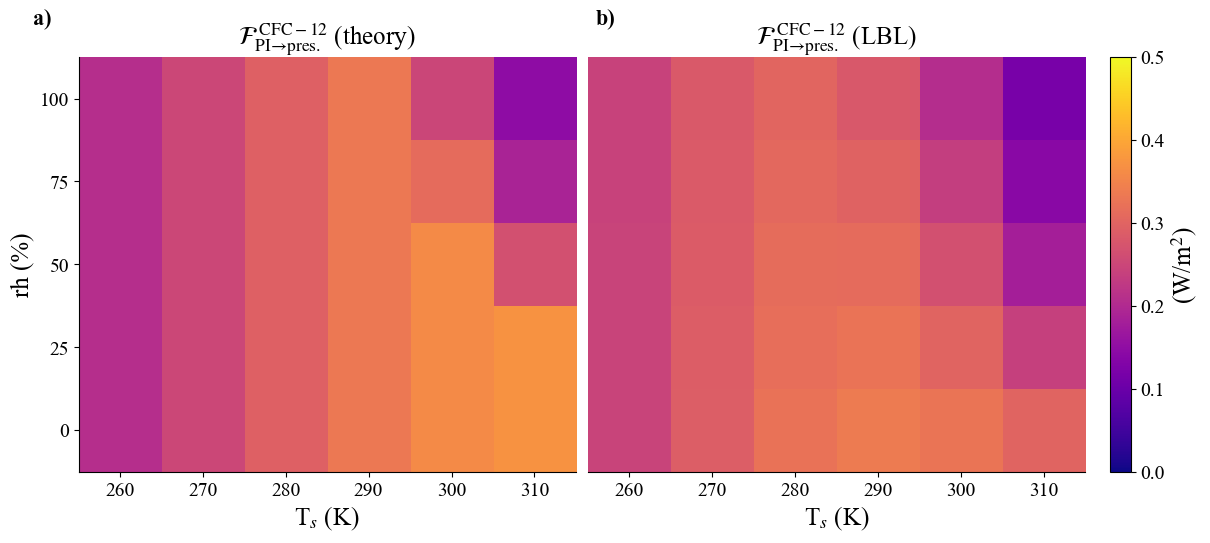

In [24]:
### Plot the figure

# set up figure
fig,(ax1, ax2) = plt.subplots(1, 2, figsize = (12, 9), layout = 'compressed')
c1 = ax1.imshow(model_forcing_raster.T, cmap = 'plasma', vmin = 0, vmax = 0.5)
c2 = ax2.imshow(ref_forcing_raster.T, cmap = 'plasma', vmin = 0, vmax = 0.5)

# y- and x-tick labels
ylabel = 100*range_rh
fig.colorbar(c2, cax = None, ticks = [0, 0.1, 0.2, 0.3, 0.4, 0.5], label = '(W/m$^2$)')
ax1.set_xticks(ticks = np.arange(len(range_Ts)), labels = range_Ts)
ax2.set_xticks(ticks = np.arange(len(range_Ts)), labels = range_Ts)
ax1.set_yticks(ticks = np.arange(len(range_rh)), labels = ylabel.astype(int))

# remove axes
sns.despine(ax = ax2, left = True)
sns.despine(ax = ax1)
ax2.yaxis.set_visible(False)

# y- and x- labels
ax1.set_title("$\mathcal{F}^{~\mathrm{CFC-12}}_{\mathrm{PI}\\to\mathrm{pres.}}$ (theory)")
ax2.set_title("$\mathcal{F}^{~\mathrm{CFC-12}}_{\mathrm{PI}\\to\mathrm{pres.}}$ (LBL)")
ax1.set_ylabel("rh (%)")
ax1.set_xlabel("T$_s$ (K)")
ax2.set_xlabel("T$_s$ (K)")
fig.text(0.03, 0.78, 'a)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.5, 0.78, 'b)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')

plt.savefig("figures/raster.pdf", bbox_inches = 'tight', dpi = 600)

plt.show()

### Figure 7
Changing parameters from CFC-12 to CO2

In [25]:
merged_data = xr.open_dataset('/data/pc2943/era5_present_tau.h5')
# CFC-12 at CO2 wavenumber
band_average_cfc12_co2_nu = np.empty((len(lats), len(longs)))

for lat_idx in range(len(lats)):
    for long_idx in range(len(longs)):
        temperature = merged_data.t.isel(latitude = lat_idx, longitude = long_idx).data
        pressure =  merged_data.level.data
        q = mpcalc.saturation_mixing_ratio(pressure[0] * units('Pa'), temperature[0] * units('K')).to('kg/kg')

        mvt_tau = tau_nu(pressure, 198, cfc12_mmr)* np.ones((len(merged_data.wavenumber.data), len(pressure)))
        band_average_cfc12_co2_nu[lat_idx, long_idx] = thin_model_linear_band_average_Bbar(temperature, pressure, merged_data.wavenumber.data, 0*mvt_tau, mvt_tau, 667, np.zeros(mvt_tau.shape), 1)

# CFC-12 with CO2 absorption coefficient fit
band_average_cfc12_co2_coeff = np.empty((len(lats), len(longs)))

for lat_idx in range(len(lats)):
    for long_idx in range(len(longs)):
        temperature = merged_data.t.isel(latitude = lat_idx, longitude = long_idx).data
        pressure =  merged_data.level.data
        q = mpcalc.saturation_mixing_ratio(pressure[0] * units('Pa'), temperature[0] * units('K')).to('kg/kg')

        mvt_tau = tau_nu(pressure, 12.5, cfc12_mmr)* np.ones((len(merged_data.wavenumber.data), len(pressure)))
        band_average_cfc12_co2_coeff[lat_idx, long_idx] = thin_model_linear_band_average_Bbar(temperature, pressure, merged_data.wavenumber.data, 0*mvt_tau, mvt_tau, 1025, np.zeros(mvt_tau.shape), 1)

# load CO2 ERA5 LBL calculations
thin_co2_data = xr.open_dataset('/data/pc2943/era5_present_tau_co2_thin.h5')

### CO2 LBL reference atmosphere
plev_ref, phlev_ref = konrad.utils.get_pressure_grids(1000e2, 1, 129)
atmosphere = konrad.atmosphere.Atmosphere(phlev_ref)
atmosphere["CO2"][:] = 1
atmosphere["O3"][:] = 0
atmosphere["T"][:] = 300
arts_atmosphere = atmosphere.to_atm_fields_compact()

# generate LBL absorption coefficients
_, _, _, _, co2_tau, co2_abs = calc_lbl_rt(arts_atmosphere, species = ["CO2"], w_grid = thin_co2_data.wavenumber.data)
mass_abs_co2 = xsec_to_mass_absorption(absorption_coeff_to_xsec(co2_abs[0, :, :-1], plev_ref, 1, atmosphere.data_vars["T"][1][0]), 44/1000)

# best fit pressure level
p_idx = 73
band_average_co2_forcing_dry = np.empty((len(lats), len(longs)))

# loop through ERA5 to fit model thin-CO2
for lat_idx in range(len(lats)):
    for long_idx in range(len(longs)):
        temperature = thin_co2_data.t.isel(latitude = lat_idx, longitude = long_idx).data
        pressure =  thin_co2_data.level.data
        q = mpcalc.saturation_mixing_ratio(pressure[0] * units('Pa'), temperature[0] * units('K')).to('kg/kg')
        rh = thin_co2_data.rh.isel(latitude = lat_idx, longitude = long_idx).data/100

        line_idealized_tau = np.zeros((len(thin_co2_data.wavenumber.data), len(pressure)))
        self_idealized_tau = np.zeros((len(thin_co2_data.wavenumber.data), len(pressure)))
        foreign_idealized_tau = np.zeros((len(thin_co2_data.wavenumber.data), len(pressure)))

        mvt_tau = tau_nu(pressure, mvt_coeff(p_idx, mass_abs_co2, thin_co2_data.wavenumber.data), cfc12_mmr)* np.ones((len(thin_co2_data.wavenumber.data), len(pressure)))
        band_average_co2_forcing_dry[lat_idx, long_idx] = thin_model_linear_band_average_Bbar(temperature, pressure, thin_co2_data.wavenumber.data, 0*mvt_tau, mvt_tau, 667, np.zeros(mvt_tau.shape), 1)

/tmp/ipykernel_2706026/608199533.py:113: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig("figures/attribution.pdf", bbox_inches = 'tight', dpi = 300)
/tmp/ipykernel_2706026/608199533.py:113: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig("figures/attribution.pdf", bbox_inches = 'tight', dpi = 300)
/home/pc2943/.conda/envs/konrad/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


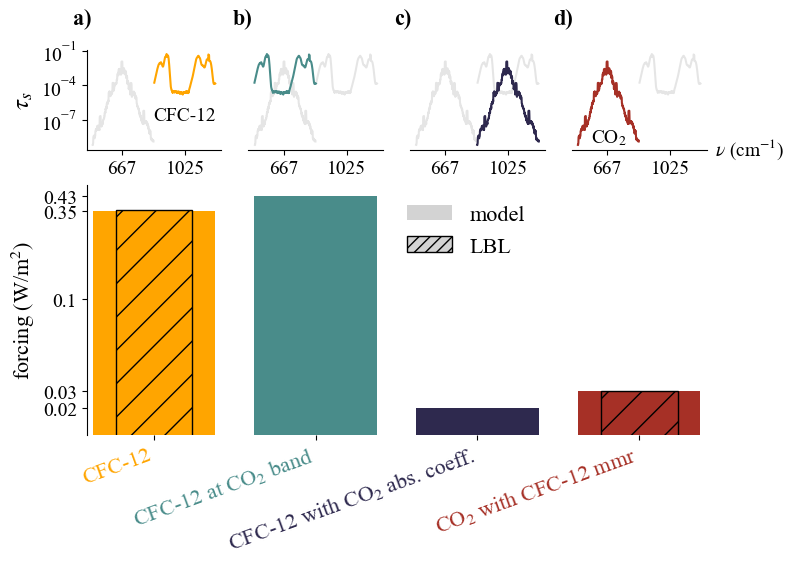

In [26]:
### Plot figure
color_scheme = np.array(['#2E294E', '#498C8A','orange', '#A63026'])

fig, axes = plt.subplots(figsize = (8,5), layout = 'compressed', sharey = 'row', sharex = 'col')
fig.clf()
gs = gridspec.GridSpec(2, 4, height_ratios=[0.4, 1])

# plot CFC-12 coefficient on axis 1
ax1 = fig.add_subplot(gs[0, 0])
ax1.semilogy(moving_average_numpy(co2_band, 10), 2*cfc12_vmr*moving_average_numpy(co2_c_tau[:, 0], 10), color = 'grey', alpha = 0.2)
ax1.semilogy(moving_average_numpy(cfc12_band, 10), 2*cfc12_vmr*moving_average_numpy(cfc12_c_tau[:, 0], 10), color = color_scheme[2])
ax1.set_ylabel("$\\tau_s$")
ax1.text(1025, 10**-7, 'CFC-12', color = 'black', fontsize = 14, horizontalalignment = 'center')

# plot CFC-12 coefficient in CO2 band on axis 2
ax2 = fig.add_subplot(gs[0, 1])
ax2.semilogy(moving_average_numpy(co2_band, 10), 2*cfc12_vmr*moving_average_numpy(co2_c_tau[:, 0], 10), color = 'grey', alpha = 0.2)
ax2.semilogy(moving_average_numpy(cfc12_band, 10), 2*cfc12_vmr*moving_average_numpy(cfc12_c_tau[:, 0], 10), color = 'grey', alpha = 0.2)
ax2.semilogy(np.linspace(500, 850, len(moving_average_numpy(cfc12_c_tau[:, 0], 10))), 2*cfc12_vmr*moving_average_numpy(cfc12_c_tau[:, 0], 10), color = color_scheme[1])

# plot CO2 coefficient in CFC-12 band on axis 3
ax3 = fig.add_subplot(gs[0, 2])
ax3.semilogy(moving_average_numpy(co2_band, 10), 2*cfc12_vmr*moving_average_numpy(co2_c_tau[:, 0], 10), color = 'grey', alpha = 0.2)
ax3.semilogy(moving_average_numpy(cfc12_band, 10), 2*cfc12_vmr*moving_average_numpy(cfc12_c_tau[:, 0], 10), color = 'grey', alpha = 0.2)
ax3.semilogy(np.linspace(850, 1200, len(moving_average_numpy(co2_c_tau[:, 0], 10))), 2*cfc12_vmr*moving_average_numpy(co2_c_tau[:, 0], 10), color = color_scheme[0])

# plot CO2 coefficient in its band on axis 4
ax4 = fig.add_subplot(gs[0, 3])
ax4.semilogy(moving_average_numpy(co2_band, 10), 2*cfc12_vmr*moving_average_numpy(co2_c_tau[:, 0], 10), color = color_scheme[3])
ax4.semilogy(moving_average_numpy(cfc12_band, 10), 2*cfc12_vmr*moving_average_numpy(cfc12_c_tau[:, 0], 10), color = 'grey', alpha = 0.2)
ax4.text(680, 10**-9, 'CO$_2$', color = 'black', fontsize = 14, horizontalalignment = 'center')

# plot results of modeling on axis 5
ax5 = fig.add_subplot(gs[1, 0])
ax5.set_ylim([0.015, 0.5])
forcings = np.array([(band_average_cfc12_forcing_dry)[5, 5], (band_average_cfc12_co2_nu)[5, 5], (band_average_cfc12_co2_coeff)[5, 5], (band_average_co2_forcing_dry)[5, 5]])
bar_colors = np.array([color_scheme[2], color_scheme[1], color_scheme[0], color_scheme[3]])
xlabs =['CFC-12', 'CFC-12 at CO$_2$ band', 'CFC-12 with CO$_2$ abs. coeff.', 'CO$_2$ with CFC-12 mmr']

ax5.bar(850, forcings[0], color = bar_colors[0])
ax5.bar(850, (np.trapz(merged_data.forcing_cfc12[5, 5], merged_data.wavenumber.data)), hatch = '/', edgecolor = 'black', color = bar_colors[0], width = 0.5)
ax5.set_xticks([850], labels = [xlabs[0]], rotation = 20, horizontalalignment = 'right', fontsize = 16, color = bar_colors[0])

ax6 = fig.add_subplot(gs[1, 1], sharey = ax5)
ax6.bar(850, forcings[1], color = bar_colors[1])
ax6.set_xticks([850], labels = [xlabs[1]], rotation = 20, horizontalalignment = 'right', fontsize = 16, color = bar_colors[1])

ax7 = fig.add_subplot(gs[1, 2], sharey = ax5)
ax7.bar(850, 0, color = 'lightgrey', label = 'model')
ax7.bar(850, 0, color = 'lightgrey', edgecolor = 'black', hatch = '///', label = 'LBL')
ax7.legend(frameon = False)
ax7.bar(850, forcings[2], color = bar_colors[2])
ax7.set_xticks([850], labels = [xlabs[2]], rotation = 20, horizontalalignment = 'right', fontsize = 16, color = bar_colors[2])

ax8 = fig.add_subplot(gs[1, 3], sharey = ax5)
ax8.bar(850, forcings[3], color = bar_colors[3])
ax8.bar(850, (np.trapz(thin_co2_data.forcing_co2.data[5, 5], thin_co2_data.wavenumber.data)), hatch = '/', edgecolor = 'black', color = bar_colors[3], width = 0.5)
ax8.set_xticks([850], labels = [xlabs[3]], rotation = 20, horizontalalignment = 'right', fontsize = 16, color = bar_colors[3])

# x-axis labels
ax5.set_ylabel("forcing (W/m$^2$)", fontsize = 16)
color_list = [color_scheme[2], color_scheme[1], color_scheme[0], color_scheme[3]]
#ax5.set_xticks([1, 2, 3, 4], labels = xlabs, rotation = 20, horizontalalignment = 'right', fontsize = 16)
#for xtick, color in zip(ax5.get_xticklabels(), color_list):
#    xtick.set_color(color)


# remove ticks
ax2.axes.get_yaxis().set_ticks([])
ax3.axes.get_yaxis().set_ticks([])
ax4.axes.get_yaxis().set_ticks([])

# remove axes, add letter labels
sns.despine()
sns.despine(ax = ax2, left = True)
sns.despine(ax = ax3, left = True)
sns.despine(ax = ax4, left = True)
sns.despine(ax = ax5, bottom = True)


fig.text(0.12, 0.93, 'a)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.32, 0.93, 'b)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.52, 0.93, 'c)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.72, 0.93, 'd)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')

ax1.set_xticks([667, 1025])
ax2.set_xticks([667, 1025])
ax3.set_xticks([667, 1025])
ax4.set_xticks([667, 1025], ['667', '1025'])

fig.text(0.91, 0.67, '$\\nu$ (cm$^{-1}$)', fontsize = 14)
ax5.set_yscale('log')

ax5.set_yticks([(band_average_cfc12_forcing_dry)[5, 5], (band_average_cfc12_co2_nu)[5, 5], (band_average_cfc12_co2_coeff)[5, 5], (band_average_co2_forcing_dry)[5, 5], 0.1], (np.round(np.array([(band_average_cfc12_forcing_dry)[5, 5], (band_average_cfc12_co2_nu)[5, 5], (band_average_cfc12_co2_coeff)[5, 5], (band_average_co2_forcing_dry)[5, 5], 0.1]), 2)))
ax5.minorticks_off()
ax1.set_yticks([10**-7, 10**-4, 10**-1])
#plt.savefig("figures/attribution.png", bbox_inches = 'tight', dpi = 300)

plt.setp(ax6.get_yticklabels(), visible=False)
ax6.tick_params(left = False)

plt.setp(ax7.get_yticklabels(), visible=False)
ax7.tick_params(left = False)

plt.setp(ax8.get_yticklabels(), visible=False)
ax8.tick_params(left = False)


sns.despine(ax = ax6, left = True, bottom = True)
sns.despine(ax = ax7, left = True, bottom = True)
sns.despine(ax = ax8, left = True, bottom = True)

plt.savefig("figures/attribution.pdf", bbox_inches = 'tight', dpi = 300)


plt.show()

### Figure 8
Planck function contours

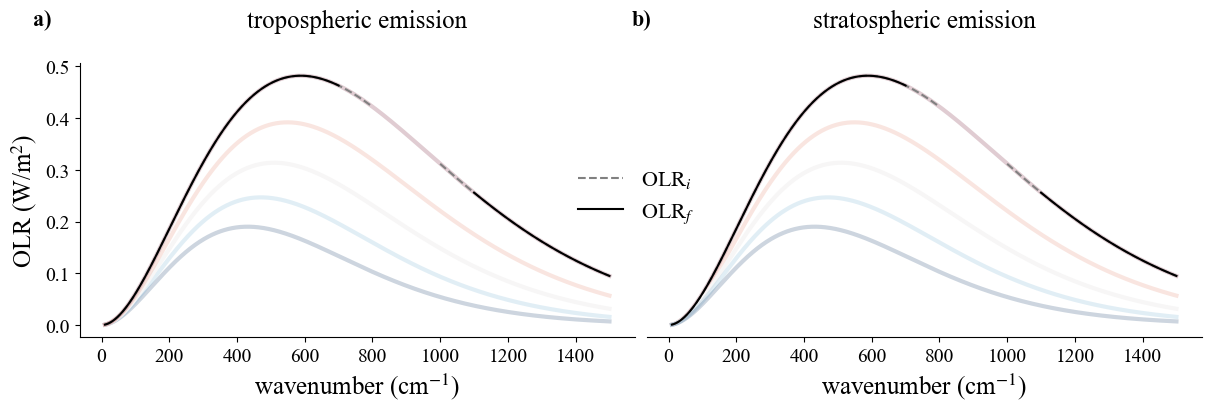

In [23]:
plev, phlev = konrad.utils.get_pressure_grids(1000e2, 1, 129)
atmosphere = konrad.atmosphere.Atmosphere(phlev)

band = np.linspace(10, 1500, 1000)
coeff = k(50, 800, 30, band)
tau = tau_profile(plev, coeff, 1, 1000, 1)
P1 = np.pi*B_nu(220, band)
P2 = np.pi*B_nu(240, band)
P3 = np.pi*B_nu(260, band)
P4 = np.pi*B_nu(280, band)
P5 = np.pi*B_nu(300, band)

bandL_unforced = np.linspace(10, 800, 1000) 
bandR_unforced = np.linspace(1000, 1500, 1000)
bandL_forced = np.linspace(10, 700, 1000)
bandR_forced = np.linspace(1100, 1500, 1000)

fig, axes = plt.subplots(1, 2, figsize = (12, 4), layout = 'compressed', sharey = True)
sns.despine()

planck_colors = plt.colormaps['RdBu_r'](np.linspace(0, 1, 5))

axes[1].plot(band, P5, color = planck_colors[4], linewidth = 3, alpha = 0.2)
axes[1].plot(band, P4, color = planck_colors[3], linewidth = 3, alpha = 0.2)
axes[1].plot(band, P3, color = planck_colors[2], linewidth = 3, alpha = 1)
axes[1].plot(band, P2, color = planck_colors[1], linewidth = 3, alpha = 0.2)
axes[1].plot(band, P1, color = planck_colors[0], linewidth = 3, alpha = 0.2)

axes[1].plot(bandL_unforced, np.pi*B_nu(300, bandL_unforced), color = 'grey', linestyle = 'dashed')
axes[1].plot(bandR_unforced, np.pi*B_nu(300, bandR_unforced), color = 'grey', linestyle = 'dashed')
axes[1].plot(bandL_forced, np.pi*B_nu(300, bandL_forced), color = 'black', linestyle = 'solid')
axes[1].plot(bandR_forced, np.pi*B_nu(300, bandR_forced), color = 'black', linestyle = 'solid')

axes[0].plot(band, P1, color = planck_colors[0], linewidth = 3, alpha = 0.2)
axes[0].plot(band, P2, color = planck_colors[1], linewidth = 3, alpha = 0.2)
axes[0].plot(band, P3, color = planck_colors[2], linewidth = 3, alpha = 1)
axes[0].plot(band, P4, color = planck_colors[3], linewidth = 3, alpha = 0.2)
axes[0].plot(band, P5, color = planck_colors[4], linewidth = 3, alpha = 0.2)

axes[0].plot(bandL_unforced, np.pi*B_nu(300, bandL_unforced), color = 'grey', linestyle = 'dashed', label = "OLR$_i$")
axes[0].plot(bandR_unforced, np.pi*B_nu(300, bandR_unforced), color = 'grey', linestyle = 'dashed')
axes[0].plot(bandL_forced, np.pi*B_nu(300, bandL_forced), color = 'black', linestyle = 'solid', label = "OLR$_f$")
axes[0].plot(bandR_forced, np.pi*B_nu(300, bandR_forced), color = 'black', linestyle = 'solid')


sns.despine(ax = axes[1], left = True)
axes[1].yaxis.set_visible(False)

axes[0].set_ylabel("OLR (W/m$^2$)")
axes[1].set_xlabel("wavenumber (cm$^{-1}$)")
axes[0].set_xlabel("wavenumber (cm$^{-1}$)")
axes[1].set_title("stratospheric emission\n")
axes[0].set_title("tropospheric emission\n")
fig.legend(frameon = False, loc = (0.47, 0.43))
fig.text(0.03, 0.95, 'a)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.53, 0.95, 'b)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')

fig.savefig("figures/OLR_schematic.png", bbox_inches = 'tight', dpi = 300)

plt.show()


### Figure 9
Maps of methane forcing.

In [38]:
### First we need to define the methane coefficient.
### Coefficient calculations

ch4_band = np.linspace(1000, 1500, 1000)
ch4_pi_vmr = 729.2e-9 # preindustrial
ch4_vmr = 1.65e-06 # present day vmr

# ARTS calculation
plev, phlev = konrad.utils.get_pressure_grids(1000e2, 1, 129)
atmosphere = konrad.atmosphere.Atmosphere(phlev)
atmosphere["CFC12"][:] = 0
atmosphere["CFC11"][:] = 0
atmosphere["CO"][:] = 0
atmosphere["O3"][:] = 0
atmosphere["CH4"][:] = 1
atmosphere["N2O"][:] = 0
atmosphere["CO2"][:] = 0

arts_atmosphere = atmosphere.to_atm_fields_compact()
_, _, _, _, ch4_tau, ch4_abs = calc_lbl_rt(arts_atmosphere, species = ["CH4"], w_grid = ch4_band)
ch4_cum_tau = arts_tau_to_cumulative(ch4_tau)
mass_abs_ch4 = xsec_to_mass_absorption(absorption_coeff_to_xsec(ch4_abs[0, :, :-1], plev, 1, atmosphere.data_vars["T"][1][0]), 16.04/1000)


In [39]:
### Water vapor in the methane band
plev, phlev = konrad.utils.get_pressure_grids(1000e2, 1, 129)
atmosphere = konrad.atmosphere.Atmosphere(phlev)


plev, phlev = konrad.utils.get_pressure_grids(1000e2, 1, 129)
atmosphere = konrad.atmosphere.Atmosphere(phlev)

# considering line only
atmosphere["CO"][:] = 0
atmosphere["H2O"][:] = 1
atmosphere["T"][:] = 245
arts_atmosphere = atmosphere.to_atm_fields_compact()
_, _, _, _, h2o_line_tau, h2o_line_abs = calc_lbl_rt(arts_atmosphere, species = ["H2O"], w_grid = ch4_band)

# convert to mass absorption
mass_abs_h2o_line = xsec_to_mass_absorption(absorption_coeff_to_xsec(h2o_line_abs[0, :, :-1], plev, 1, atmosphere.data_vars["T"][1][0]), 18.01/1000)

# reference values
rh_ref = 0.75
T_ref_cont = 275
T_ref_line = 245
p_ref = (plev)[19]
k_ref_line = mass_abs_h2o_line[:, 19]


In [40]:
### Idealized coefficient parameters

# emission optical depths
t_em = 0.82
tau_em_h2o = 0.7

# H2O coefficient parameters
line_k, line_l = 3.8, 35

# CH4 coefficient parameters
param_array = np.array([[11, 42, 125, 14, 0.5]])
band1_start, band1_end = 310, 920 # band splits by index
band2_start, band2_end = 920, 980
band1 = ch4_band[band1_start:band1_end]
band2= ch4_band[band2_start:band2_end]
beta1, beta2 = 2, 2
k1 = param_array[0, 0]
l1 = param_array[0, 1]
k2 = param_array[0, 2]
l2 = param_array[0, 3]
band1_avg = param_array[0, 4]

# idealized absorption coefficients
k_ref_1 = k(k1, ch4_band[band1_end - 1], l1, band1)
k_ref_2 = k(k2, ch4_band[band2_end - 1], l2, band2)

# reference absorption coefficient
ref_idx = 39
abs_ref = np.sort(mass_abs_ch4[:, ref_idx])
sort_idx = sorted(range(len(mass_abs_ch4[:, ref_idx])), key = lambda k: mass_abs_ch4[:, ref_idx][k])

# turn vmr to mmr 
ch4_mmr = (16.04/28.8)*ch4_vmr
ch4_pi_mmr = (16.04/28.8)*ch4_pi_vmr

In [41]:
# run methane schematic first

t_em = 0.82
tau_em_h2o = 0.7
line_k, line_l= 3.8, 35

era = xr.open_dataset('/data/pc2943/ERA5_March1981_monthlymean.nc', engine = "netcdf4")
lats = era.latitude.data[::72]# merged_data.latitude.data
longs = np.array([0.,  36.25,  72.5 , 108.75, 145.  , 181.25, 217.5 , 253.75,
       290.  , 326.25, 3.5975e+02]) #merged_data.longitude.data


band_average_ch4_forcing_dry = np.empty((len(lats), len(longs)))
band_average_ch4_forcing_dry_4x = np.empty((len(lats), len(longs)))

lbl_ch4_forcing_dry = np.empty((len(lats), len(longs)))
lbl_ch4_forcing_dry_4x = np.empty((len(lats), len(longs)))


### calculate forcing for dry/methane-only atmosphere
for lat_idx in range(len(lats)):
    for long_idx in range(len(longs)):
        if lat_idx == 0 or lat_idx == len(lats) - 1:
            if long_idx == 0:
                profile_data = xr.open_dataset('/data/pc2943/era5_ch4_' + str(lat_idx) + '_' + str(long_idx) + '.h5', engine = "netcdf4")
        
        else:
            profile_data = xr.open_dataset('/data/pc2943/era5_ch4_' + str(lat_idx) + '_' + str(long_idx) + '.h5', engine = "netcdf4")
  
        
        temperature = profile_data.t.data[0, 0]
        pressure =  profile_data.level.data

        q = mpcalc.saturation_mixing_ratio(pressure[0] * units('Pa'), temperature[0] * units('K')).to('kg/kg')
        rh = profile_data.rh.data/100

        line_idealized_tau = np.zeros((len(ch4_band), len(pressure)))
        self_idealized_tau = np.zeros((len(ch4_band), len(pressure)))
        foreign_idealized_tau = np.zeros((len(ch4_band), len(pressure)))

        band_average_ch4_forcing_dry[lat_idx, long_idx] = thin_model_linear_band_average_Bbar(temperature, pressure, band1, tau_profile(pressure, np.array([band1_avg]), ch4_pi_mmr, plev[ref_idx], beta1).T*np.ones((len(band1), len(pressure))), tau_profile(pressure, np.array([band1_avg]), ch4_mmr, plev[ref_idx], beta1).T*np.ones((len(band1), len(pressure))), 1305, (line_idealized_tau + self_idealized_tau + foreign_idealized_tau)[band1_start:band1_end], tau_em_h2o) + thick_model_triangle(pressure, temperature, k2, l2, 1305, ch4_pi_mmr, ch4_mmr, plev[ref_idx], beta2, band2, 0.82, (line_idealized_tau + self_idealized_tau + foreign_idealized_tau)[band2_start:band2_end], tau_em_h2o)

        band_average_ch4_forcing_dry_4x[lat_idx, long_idx] = thin_model_linear_band_average_Bbar(temperature, pressure, band1, tau_profile(pressure, np.array([band1_avg]), ch4_mmr, plev[ref_idx], beta1).T*np.ones((len(band1), len(pressure))), tau_profile(pressure, np.array([band1_avg]), 4*ch4_mmr, plev[ref_idx], beta1).T*np.ones((len(band1), len(pressure))), 1305, (line_idealized_tau + self_idealized_tau + foreign_idealized_tau)[band1_start:band1_end], tau_em_h2o) + thick_model_triangle(pressure, temperature, k2, l2, 1305, ch4_mmr, 4*ch4_mmr, plev[ref_idx], beta2, band2, 0.82, (line_idealized_tau + self_idealized_tau + foreign_idealized_tau)[band2_start:band2_end], tau_em_h2o)

        lbl_ch4_forcing_dry[lat_idx, long_idx] = np.trapz(profile_data.forcing_ch4_PI.data, profile_data.wavenumber.data)
        lbl_ch4_forcing_dry_4x[lat_idx, long_idx] = np.trapz(profile_data.forcing_ch4_4x.data, profile_data.wavenumber.data)



### calculate forcing for atmosphere with H2O overlap
band_average_ch4_forcing_h2o = np.empty((len(lats), len(longs)))
band_average_ch4_forcing_h2o_4x = np.empty((len(lats), len(longs)))
tau_em_h2o = 0.7
tau_em = 0.82

lbl_ch4_forcing_w_h2o = np.empty((len(lats), len(longs)))
lbl_ch4_forcing_w_h2o_4x = np.empty((len(lats), len(longs)))


for lat_idx in range(len(lats)):
    for long_idx in range(len(longs)):
        if lat_idx == 0 or lat_idx == len(lats) - 1:
            if long_idx == 0:
                profile_data = xr.open_dataset('/data/pc2943/era5_ch4_' + str(lat_idx) + '_' + str(long_idx) + '.h5', engine = "netcdf4")
        
        else:
            profile_data = xr.open_dataset('/data/pc2943/era5_ch4_' + str(lat_idx) + '_' + str(long_idx) + '.h5', engine = "netcdf4")
  
        temperature = profile_data.t.data[0, 0]
        pressure =  profile_data.level.data
        q = mpcalc.saturation_mixing_ratio(pressure[0] * units('Pa'), temperature[0] * units('K')).to('kg/kg')
        rh = profile_data.rh.data/100

        line_idealized_tau = np.zeros((len(ch4_band), len(pressure)))
        self_idealized_tau = np.zeros((len(ch4_band), len(pressure)))
        foreign_idealized_tau = np.zeros((len(ch4_band), len(pressure)))

        for nu_idx, nu in enumerate(ch4_band):
            line_idealized_tau[nu_idx, :] = line_tau(k(line_k, 1450, line_l, ch4_band)[sort_idx][nu_idx], pressure, p_ref, temperature, rh)

        band_average_ch4_forcing_h2o[lat_idx, long_idx] = thin_model_linear_band_average_Bbar(temperature, pressure, band1, tau_profile(pressure, np.array([band1_avg]), ch4_pi_mmr, plev[ref_idx], beta1).T*np.ones((len(band1), len(pressure))), tau_profile(pressure, np.array([band1_avg]), ch4_mmr, plev[ref_idx], beta1).T*np.ones((len(band1), len(pressure))), 1305, (line_idealized_tau + self_idealized_tau + foreign_idealized_tau)[band1_start:band1_end], tau_em_h2o) + thick_model_triangle(pressure, temperature, k2, l2, 1305, ch4_pi_mmr, ch4_mmr, plev[ref_idx], beta2, band2, tau_em, (line_idealized_tau + self_idealized_tau + foreign_idealized_tau)[band2_start:band2_end], tau_em_h2o)

        band_average_ch4_forcing_h2o_4x[lat_idx, long_idx] =  thin_model_linear_band_average_Bbar(temperature, pressure, band1, tau_profile(pressure, np.array([band1_avg]), ch4_mmr, plev[ref_idx], beta1).T*np.ones((len(band1), len(pressure))), tau_profile(pressure, np.array([band1_avg]), 4*ch4_mmr, plev[ref_idx], beta1).T*np.ones((len(band1), len(pressure))), 1305, (line_idealized_tau + self_idealized_tau + foreign_idealized_tau)[band1_start:band1_end], tau_em_h2o) + thick_model_triangle(pressure, temperature, k2, l2, 1305, ch4_mmr, 4*ch4_mmr, plev[ref_idx], beta2, band2, tau_em, (line_idealized_tau + self_idealized_tau + foreign_idealized_tau)[band2_start:band2_end], tau_em_h2o)

        lbl_ch4_forcing_w_h2o[lat_idx, long_idx] = np.trapz(profile_data.forcing_w_h2o_PI.data, profile_data.wavenumber.data)
        lbl_ch4_forcing_w_h2o_4x[lat_idx, long_idx] = np.trapz(profile_data.forcing_w_h2o_4x.data, profile_data.wavenumber.data)




In [42]:
# methane global means.
era5_areas = area_grid(lats, longs)
lbl_ch4_global_mean = np.sum(lbl_ch4_forcing_dry*era5_areas / np.sum(era5_areas))
lbl_ch4_w_h2o_global_mean = np.sum(lbl_ch4_forcing_w_h2o*era5_areas / np.sum(era5_areas))
lbl_ch4_global_mean_4x = np.sum(lbl_ch4_forcing_dry_4x*era5_areas / np.sum(era5_areas))
lbl_ch4_w_h2o_global_mean_4x = np.sum(lbl_ch4_forcing_w_h2o_4x*era5_areas / np.sum(era5_areas))

theory_ch4_global_mean = np.sum(band_average_ch4_forcing_dry*era5_areas / np.sum(era5_areas))
theory_ch4_w_h2o_global_mean = np.sum(band_average_ch4_forcing_h2o*era5_areas / np.sum(era5_areas))
theory_ch4_global_mean_4x = np.sum(band_average_ch4_forcing_dry_4x*era5_areas / np.sum(era5_areas))
theory_ch4_w_h2o_global_mean_4x = np.sum(band_average_ch4_forcing_h2o_4x*era5_areas / np.sum(era5_areas))


/tmp/ipykernel_2053196/636616407.py:25: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = fig.colorbar(plt.cm.ScalarMappable(norm=colors.Normalize(vmin=0, vmax=2), cmap='plasma'), cax = None, ticks = [0, 0.5, 1, 1.5, 2])
/tmp/ipykernel_2053196/636616407.py:58: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = fig.colorbar(plt.cm.ScalarMappable(norm=colors.Normalize(vmin=0, vmax=2), cmap='plasma'), cax = None, ticks = [0, 0.5, 1, 1.5, 2])
/tmp/ipykernel_2053196/636616407.py:88: MatplotlibDeprecationWarning: Unable to dete

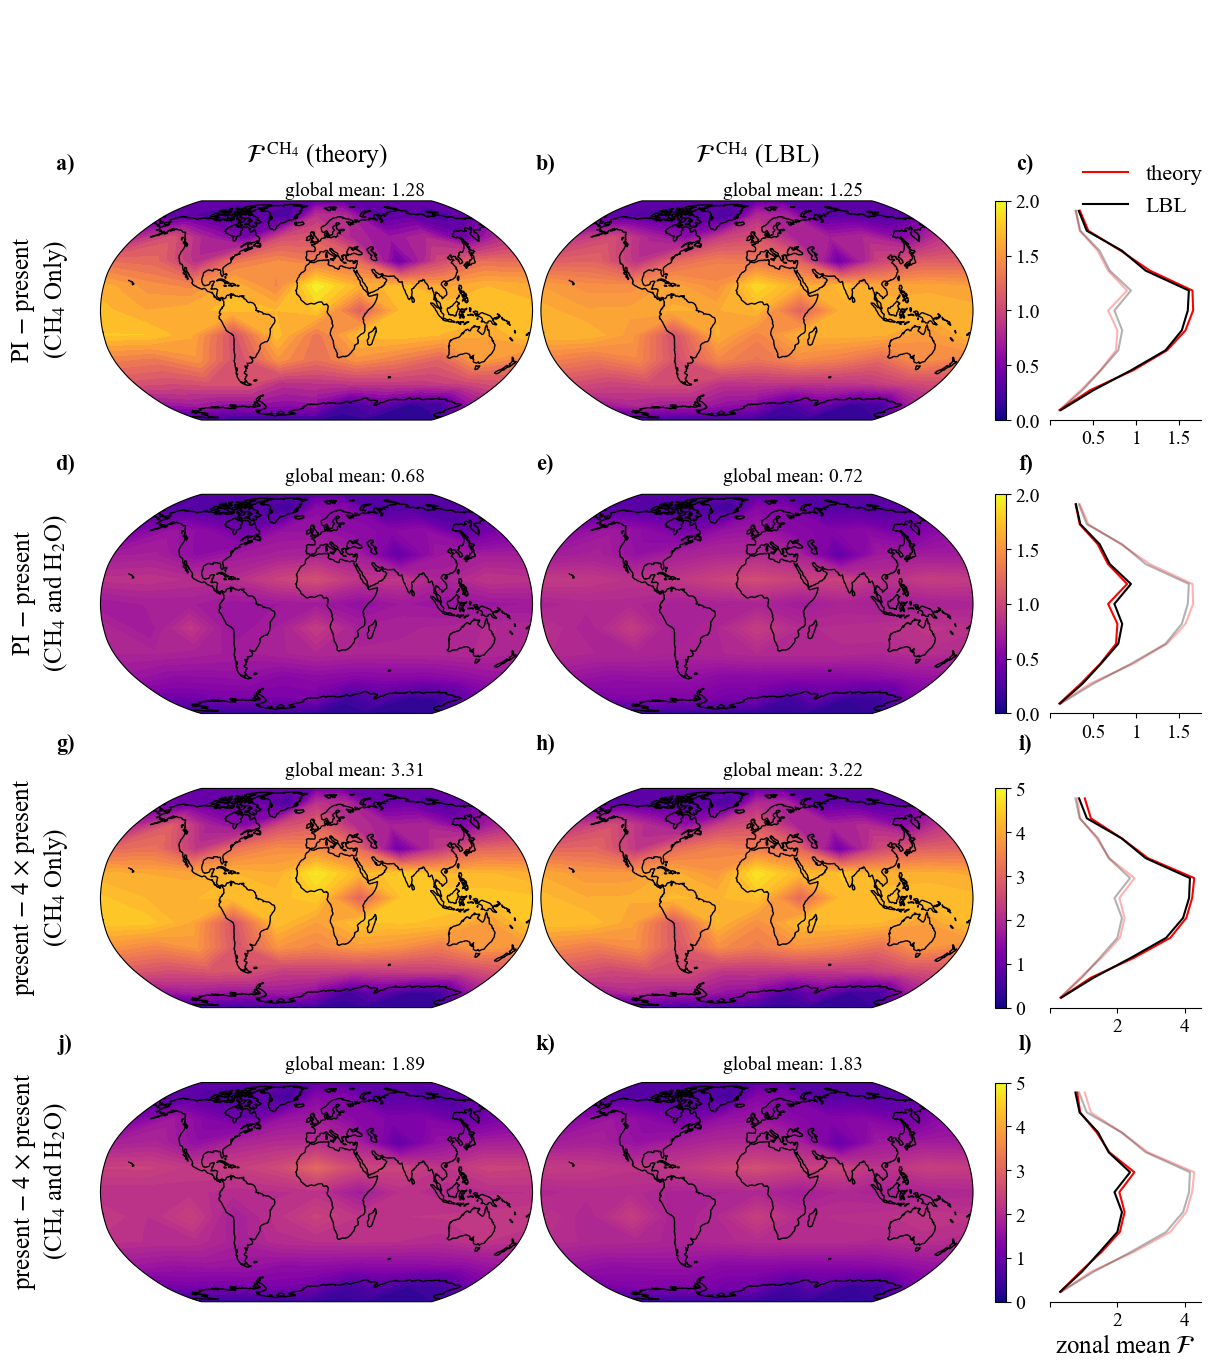

In [45]:
        
### Plot figures
# import map packages

fig = plt.figure(figsize = (12, 20),layout = 'compressed')
gs = fig.add_gridspec(4, 3, width_ratios=[1,1,0.35], height_ratios = [1, 1, 1, 1])

# PI - present day model
ax1 = fig.add_subplot(gs[0, 0], projection = ccrs.Robinson())
c1 = ax1.contourf(longs, lats, band_average_ch4_forcing_dry, 30, 
                transform = ccrs.PlateCarree(), cmap = 'plasma', norm=colors.Normalize(vmin=0, vmax=2))
ax1.coastlines()
ax1.set_title("$\mathcal{F}^{~\mathrm{CH_4}}$ (theory)\n")
ax1.text(-0.07, 0.55, 'PI $-$ present \n(CH$_4$ Only)', va='bottom', ha='center',
        rotation='vertical', rotation_mode='anchor',
        transform=ax1.transAxes, fontsize = 18)

# PI to present day LBL
ax2 = fig.add_subplot(gs[0, 1], projection = ccrs.Robinson())
c2 = ax2.contourf(longs, lats, 
                lbl_ch4_forcing_dry,
                30, transform = ccrs.PlateCarree(), cmap = 'plasma', norm=colors.Normalize(vmin=0, vmax=2))


#fig.colorbar(c2, cax = None, ticks = [0, 0.5, 1, 1.5])
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=colors.Normalize(vmin=0, vmax=2), cmap='plasma'), cax = None, ticks = [0, 0.5, 1, 1.5, 2])

ax2.coastlines()
ax2.set_title("$\mathcal{F}^{~\mathrm{CH_4}}$ (LBL)\n")

# PI to present day zonal mean
axmean = fig.add_subplot(gs[0, 2])
axmean.plot(np.mean(band_average_ch4_forcing_dry, axis = -1), lats, color = 'red', label = 'theory')
axmean.plot(np.mean(lbl_ch4_forcing_dry, axis = -1), lats, color = 'black', label = 'LBL')
axmean.plot(np.mean(band_average_ch4_forcing_h2o, axis = -1), lats, color = 'red', alpha = 0.3)
axmean.plot(np.mean(lbl_ch4_forcing_w_h2o, axis = -1), lats, color = 'black', alpha = 0.3)
axmean.set_xlabel("$~$")
sns.despine(ax = axmean, left = True)
axmean.yaxis.set_visible(False)
axmean.set_xlim([0, 1.75])
fig.legend(frameon = False, loc = (0.885, 0.835))
axmean.set_xticks([0, 0.5, 1, 1.5], labels = ['$~$', '0.5', '1', '1.5'])


# PI to present day forcing model
ax1 = fig.add_subplot(gs[1, 0], projection = ccrs.Robinson())
c1 = ax1.contourf(longs, lats, band_average_ch4_forcing_h2o, 30, 
                transform = ccrs.PlateCarree(), cmap = 'plasma', norm=colors.Normalize(vmin=0, vmax=2))
ax1.coastlines()
ax1.text(-0.07, 0.55, 'PI $-$ present \n(CH$_4$ and H$_2$O)', va='bottom', ha='center',
        rotation='vertical', rotation_mode='anchor',
        transform=ax1.transAxes, fontsize = 18)

# PI to present-day LBL
ax2 = fig.add_subplot(gs[1, 1], projection = ccrs.Robinson())
c2 = ax2.contourf(longs, lats, lbl_ch4_forcing_w_h2o,
                30, transform = ccrs.PlateCarree(), cmap = 'plasma', norm=colors.Normalize(vmin=0, vmax=2))
#fig.colorbar(c2, cax = None, ticks = [0.5, 1, 1.5])
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=colors.Normalize(vmin=0, vmax=2), cmap='plasma'), cax = None, ticks = [0, 0.5, 1, 1.5, 2])

ax2.coastlines()

# PI to present day zonal mean
ax3 = fig.add_subplot(gs[1, 2], sharex = axmean)
ax3.plot(np.mean(band_average_ch4_forcing_h2o, axis = -1), lats, color = 'red')
ax3.plot(np.mean(lbl_ch4_forcing_w_h2o, axis = -1), lats, color = 'black')
ax3.plot(np.mean(band_average_ch4_forcing_dry, axis = -1), lats, color = 'red', alpha = 0.3)
ax3.plot(np.mean(lbl_ch4_forcing_dry, axis = -1), lats, color = 'black', alpha = 0.3)
ax3.set_xticks([0, 0.5, 1, 1.5], labels = ['$~$', '0.5', '1', '1.5'])
ax3.set_xlabel("$~$")
sns.despine(ax = ax3, left = True)
ax3.yaxis.set_visible(False)

# present-day to 4x present day model
ax4 = fig.add_subplot(gs[2, 0], projection = ccrs.Robinson())
c1 = ax4.contourf(longs, lats, band_average_ch4_forcing_dry_4x, 30, 
                transform = ccrs.PlateCarree(), cmap = 'plasma', norm=colors.Normalize(vmin=0, vmax=5))
ax4.coastlines()
ax4.text(-0.07, 0.55, 'present $-$ 4 $\\times$ present \n(CH$_4$ Only)', va='bottom', ha='center',
        rotation='vertical', rotation_mode='anchor',
        transform=ax4.transAxes, fontsize = 18)

# present day to 4x present day LBL
ax5 = fig.add_subplot(gs[2, 1], projection = ccrs.Robinson())
c2 = ax5.contourf(longs, lats, 
                lbl_ch4_forcing_dry_4x,
                30, transform = ccrs.PlateCarree(), cmap = 'plasma', norm=colors.Normalize(vmin=0, vmax=5))
#fig.colorbar(c2, cax = None, ticks = [0, 1, 2, 3, 4, 5, 6])
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=colors.Normalize(vmin=0, vmax=5), cmap='plasma'), cax = None, ticks = [0, 1, 2, 3, 4, 5])

ax5.coastlines()

# present day to 4x present day zonal mean
ax6 = fig.add_subplot(gs[2, 2])
ax6.plot(np.mean(band_average_ch4_forcing_dry_4x, axis = -1), lats, color = 'red')
ax6.plot(np.mean(lbl_ch4_forcing_dry_4x, axis = -1), lats, color = 'black')
ax6.plot(np.mean(band_average_ch4_forcing_h2o_4x, axis = -1), lats, color = 'red', alpha = 0.3)
ax6.plot(np.mean(lbl_ch4_forcing_w_h2o_4x, axis = -1), lats, color = 'black', alpha = 0.3)
ax6.set_xlabel("$~$")
ax6.set_xticks([0, 2, 4], ['$~$', '2', '4'])
sns.despine(ax = ax6, left = True)
ax6.yaxis.set_visible(False)

# present-day to 4x present day model
ax4 = fig.add_subplot(gs[3, 0], projection = ccrs.Robinson())
c1 = ax4.contourf(longs, lats, band_average_ch4_forcing_h2o_4x, 30, 
                transform = ccrs.PlateCarree(), cmap = 'plasma', norm=colors.Normalize(vmin=0, vmax=5))
ax4.coastlines()
ax4.text(-0.07, 0.55, 'present $-$ 4 $\\times$ present \n(CH$_4$ and H$_2$O)', va='bottom', ha='center',
        rotation='vertical', rotation_mode='anchor',
        transform=ax4.transAxes, fontsize = 18)

# present-day to 4x present day LBL
ax5 = fig.add_subplot(gs[3, 1], projection = ccrs.Robinson())
c2 = ax5.contourf(longs, lats, 
                lbl_ch4_forcing_w_h2o_4x,
                30, transform = ccrs.PlateCarree(), cmap = 'plasma', norm=colors.Normalize(vmin=0, vmax=5))
#fig.colorbar(c2, cax = None, ticks = [0, 1, 2, 3, 4, 5, 6])
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=colors.Normalize(vmin=0, vmax=5), cmap='plasma'), cax = None, ticks = [0, 1, 2, 3, 4, 5])

ax5.coastlines()

# present-day to 4x present-day zonal mean
ax6 = fig.add_subplot(gs[3, 2], sharex = ax6)
ax6.plot(np.mean(band_average_ch4_forcing_h2o_4x, axis = -1), lats, color = 'red')
ax6.plot(np.mean(lbl_ch4_forcing_w_h2o_4x, axis = -1), lats, color = 'black')
ax6.plot(np.mean(band_average_ch4_forcing_dry_4x, axis = -1), lats, color = 'red', alpha = 0.3)
ax6.plot(np.mean(lbl_ch4_forcing_dry_4x, axis = -1), lats, color = 'black', alpha = 0.3)
ax6.set_xticks([0, 2, 4], ['$~$', '2', '4'])

ax6.set_xlabel("zonal mean $\mathcal{F}$")
sns.despine(ax = ax6, left = True)
ax6.yaxis.set_visible(False)

# set labels
fig.text(0.05, 0.79, 'a)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.45, 0.79, 'b)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.85, 0.79, 'c)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.05, 0.64, 'd)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.45, 0.64, 'e)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.85, 0.64, 'f)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.05, 0.5, 'g)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.45, 0.5, 'h)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.85, 0.5, 'i)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.05, 0.35, 'j)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.45, 0.35, 'k)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.85, 0.35, 'l)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')

fig.text(0.35, 0.777, ("global mean: %.2f" %(theory_ch4_global_mean)), color = 'black', fontsize = 14, ha = 'right')
fig.text(0.715, 0.777, ("global mean: %.2f" %(lbl_ch4_global_mean)), color = 'black', fontsize = 14, ha = 'right')

fig.text(0.35, 0.634, ("global mean: %.2f" %(theory_ch4_w_h2o_global_mean)), color = 'black', fontsize = 14, ha = 'right')
fig.text(0.715, 0.634, ("global mean: %.2f" %(lbl_ch4_w_h2o_global_mean)), color = 'black', fontsize = 14, ha = 'right')

fig.text(0.35, 0.487, ("global mean: %.2f" %(theory_ch4_global_mean_4x)), color = 'black', fontsize = 14, ha = 'right')
fig.text(0.715, 0.487, ("global mean: %.2f" %(lbl_ch4_global_mean_4x)), color = 'black', fontsize = 14, ha = 'right')

fig.text(0.35, 0.34, ("global mean: %.2f" %(theory_ch4_w_h2o_global_mean_4x)), color = 'black', fontsize = 14, ha = 'right')
fig.text(0.715, 0.34, ("global mean: %.2f" %(lbl_ch4_w_h2o_global_mean_4x)), color = 'black', fontsize = 14, ha = 'right')

plt.savefig("figures/methane_maps.png", bbox_inches = 'tight', dpi = 300)

plt.show()

### Figure 10
N$_2$O $v_1$ band forcing

In [36]:
### Line-by-line N2O forcing
n2o_band = np.linspace(500, 1500, 2000) #n2o emits across the longwave spectrum
n2o_pi_vmr = 270e-09 # n2o preindustrial concentrations
n2o_vmr = 332.1e-09
n2o_pi_mmr = (44.013/28.8)*n2o_pi_vmr
n2o_mmr = (44.013/28.8)*n2o_vmr

present_mult = n2o_vmr/n2o_pi_vmr

# multipls of pre-industrial vmr to examine
c = np.array([2, 4, 6, 8, 10, 12, 14, 16])*n2o_pi_vmr

n2o_step = np.zeros((len(c), len(n2o_band)))

# preindustrial OLR
n2o_present_OLR = flux_up_profile(atmosphere.data_vars["T"][1][0], plev, 2*n2o_pi_vmr*n2o_c_tau.T, n2o_band)[-1]

# track cumulative optical depth at surface
tau_ground = np.empty((len(c), len(n2o_band)))

# loop through concentrations
for c_idx, conc in enumerate(c):

    # perturbed OLR
    n2o_temp_OLR = flux_up_profile(atmosphere.data_vars["T"][1][0], plev, 2*conc*n2o_c_tau.T, n2o_band)[-1]
    tau_ground[c_idx, :] = 2*conc*n2o_c_tau[:, 0]

    # subtract from pre-industrial OLR for forcing
    n2o_step[c_idx, :] = n2o_present_OLR - n2o_temp_OLR

### Analysis

n2o_temp_OLR = flux_up_profile(atmosphere.data_vars["T"][1][0], plev, 2*n2o_vmr*n2o_c_tau.T, n2o_band)[-1]
present_forcing_n2o = n2o_present_OLR - n2o_temp_OLR

# where to split the bands by index
band1_start = 70
band1_end = 290
band2_start = 1200
band2_end = 1430
band3_start = 1430
band3_end = 1700

band1 = n2o_band[band1_start:band1_end]
band2 = n2o_band[band2_start:band2_end]
band3 = n2o_band[band3_start:band3_end]

# total forcing in each band
f1_int = np.trapz(n2o_step[:, band1_start:band1_end], band1, axis = 1)
f2_int = np.trapz(n2o_step[:, band2_start:band2_end], band2, axis = 1)
f3_int = np.trapz(n2o_step[:, band3_start:band3_end], band3, axis = 1)
n2o_present_band1 = np.trapz(present_forcing_n2o[band1_start:band1_end], band1)
n2o_present_band2 = np.trapz(present_forcing_n2o[band2_start:band2_end], band2)
n2o_present_band3 = np.trapz(present_forcing_n2o[band3_start:band3_end], band3)

# alpha and beta values
alpha1, beta1 = 2, 2
alpha2, beta2 = 6, 2
alpha3, beta3 = 6.5, 2

lapse = 7 # avg. tropospheric value
R = 287
g = 9.8
gamma1 = (alpha1/beta1)*((R/g)*(lapse/1000))
gamma2 = (alpha2/beta2)*((R/g)*(lapse/1000))
gamma3 = (alpha3/beta3)*((R/g)*(lapse/1000))

# determine emission optical thickness
tau_em1 = sp.special.gamma(1 + gamma1)**(1/(gamma1))
tau_em2 = sp.special.gamma(1 + gamma2)**(1/(gamma2))
tau_em3 = sp.special.gamma(1 + gamma3)**(1/(gamma3))

### Band3 Model Calculations

subband = np.linspace(1220, 1340, 400)

plev, phlev = konrad.utils.get_pressure_grids(1000e2, 1, 129)
atmosphere = konrad.atmosphere.Atmosphere(phlev)
T, h2o_vmr, q = create_profile_moist(250, 0, plev)
atmosphere["CFC12"][:] = 0
atmosphere["CFC11"][:] = 0
atmosphere["CO"][:] = 0
atmosphere["O3"][:] = 0
atmosphere["CH4"][:] = 0
atmosphere["N2O"][:] = 1
atmosphere["CO2"][:] = 0
atmosphere["T"][:] = 250

arts_atmosphere = atmosphere.to_atm_fields_compact()
_, _, _, _, _, n2o_ref_abs = calc_lbl_rt(arts_atmosphere, species = ["N2O"], w_grid = subband)
mass_abs_n2o = xsec_to_mass_absorption(absorption_coeff_to_xsec(n2o_ref_abs[0, :, :-1], plev, 1, atmosphere.data_vars["T"][1][0]), 44.014/1000)

idx1, idx2, idx3 = 180, 228, 270
k1, l1, nu1  = 40, 7, 1275 #65, 8
band3_1, abs1 = subband[:idx1], k(k1, nu1, l1, subband[:idx1]) #180
band3_2, abs2 = subband[idx1:idx2], k(k1, nu1, l1, subband[idx1:idx2])
k2, l2, nu2 = 40, 6, 1300 #65, 5
band3_3, abs3 = subband[idx2:idx3], k(k2, nu2, l2, subband[idx2:idx3]) #270
band3_4, abs4= subband[idx3:], k(k2, nu2, l2, subband[idx3:])

plev, phlev = konrad.utils.get_pressure_grids(1000e2, 1, 129)
atmosphere = konrad.atmosphere.Atmosphere(phlev)

n2o_band3_model = np.empty(len(c))
for c_idx, conc in enumerate(c):
    n2o_band3_model[c_idx] =  thick_model_triangle(plev, atmosphere.data_vars["T"][1][0], k1, l1, nu1, n2o_pi_mmr, conc*(44.013/28.8), plev[39], 2, band3_1, 0.86, np.zeros((len(plev), len(subband))), 0.7) + thick_model_triangle(plev, atmosphere.data_vars["T"][1][0], k1, l1, nu1, n2o_pi_mmr, conc*(44.013/28.8), plev[39], 2, band3_2, 0.86, np.zeros((len(plev), len(subband))), 0.7) + thick_model_triangle(plev, atmosphere.data_vars["T"][1][0], k2, l2, nu2, n2o_pi_mmr, conc*(44.013/28.8), plev[39], 2, band3_3, 0.86, np.zeros((len(plev), len(subband))), 0.7) + thick_model_triangle(plev, atmosphere.data_vars["T"][1][0], k2, l2, nu2, n2o_pi_mmr, conc*(44.013/28.8), plev[39], 2, band3_4, 0.86, np.zeros((len(plev), len(subband))), 0.7)

n2o_present =  thick_model_triangle(plev, atmosphere.data_vars["T"][1][0], k1, l1, nu1, n2o_pi_mmr, n2o_mmr, plev[39], 2, band3_1, 0.86, np.zeros((len(plev), len(subband))), 0.7) + thick_model_triangle(plev, atmosphere.data_vars["T"][1][0], k1, l1, nu1, n2o_pi_mmr, n2o_mmr, plev[39], 2, band3_2, 0.86, np.zeros((len(plev), len(subband))), 0.7) + thick_model_triangle(plev, atmosphere.data_vars["T"][1][0], k2, l2, nu2, n2o_pi_mmr, n2o_mmr, plev[39], 2, band3_3, 0.86, np.zeros((len(plev), len(subband))), 0.7) + thick_model_triangle(plev, atmosphere.data_vars["T"][1][0], k2, l2, nu2, n2o_pi_mmr, n2o_mmr, plev[39], 2, band3_4, 0.86, np.zeros((len(plev), len(subband))), 0.7)

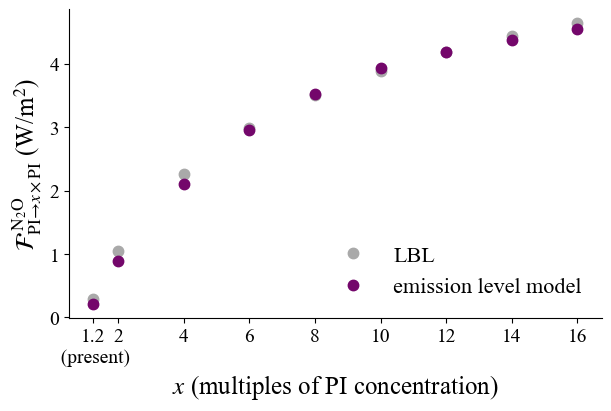

In [38]:
# plot model figure
fig, ax = plt.subplots(1, 1, figsize = (6, 4), layout = 'compressed')

band1_color = '#5B9279' #'teal'
band2_color = '#3B5171' #'navy'
band3_color = '#74076B' #'purple'

# plot modelled band3
ax.plot(c, f3_int, '.', markersize = 15, color = 'darkgrey', label = 'LBL')
ax.plot(c, n2o_band3_model, '.', color = band3_color, markersize = 15, label = 'emission level model')
ax.plot(present_mult*n2o_pi_vmr, n2o_present_band3, '.', markersize = 15, color = 'darkgrey')
ax.plot(present_mult*n2o_pi_vmr, n2o_present, '.', color = band3_color, markersize = 15)
ax.set_xticks(np.concatenate([np.array([present_mult*n2o_pi_vmr]), c]), np.concatenate([np.array([str(np.round(present_mult, 1)) + '\n (present)']), np.round(c/n2o_pi_vmr, 1).astype(int)]))

ax.legend(frameon = False)
ax.set_ylabel("$\mathcal{F}^\mathrm{~N_2O}_{\mathrm{PI} \\to x \\times \mathrm{PI}}$ (W/m$^2$)")

sns.despine(fig)
ax.set_xlabel("$x$ (multiples of PI concentration)")
fig.savefig("figures/band3_forcing.pdf", bbox_inches = 'tight', dpi = 300)

plt.show()

### Figure 11
N$_2$O across the longwave.

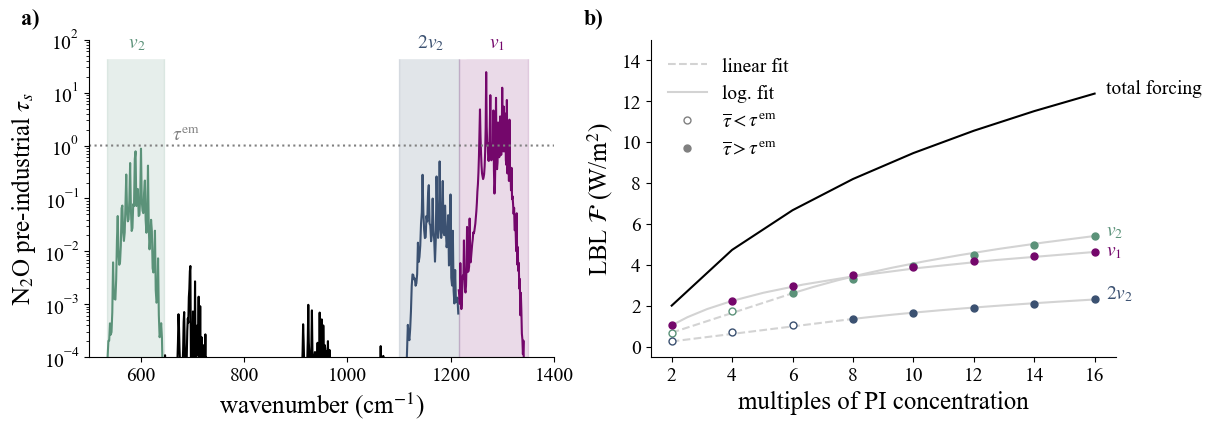

In [39]:
### Plot figure

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 4), layout = 'compressed')

# plot the individual bands
ax1.semilogy(n2o_band[band1_end:band2_start][::2], 0.5*tau_ground[0, :][band1_end:band2_start][::2], color = 'black')
ax1.semilogy(n2o_band[band1_start:band1_end][2::3], 0.5*tau_ground[0, :][band1_start:band1_end][2::3], color = band1_color)
ax1.semilogy(n2o_band[band2_start:band2_end][::3], 0.5*tau_ground[0, :][band2_start:band2_end][::3], color = band2_color)
ax1.semilogy(band3[::2], 0.5*tau_ground[0, :][band3_start:band3_end][::2], color = band3_color)

# color code
ax1.axvspan(band1[0], band1[-1], color=band1_color, alpha=0.15)
ax1.axvspan(band2[0], band2[-1], color=band2_color, alpha=0.15)
ax1.axvspan(band3[0], band3[-1], color=band3_color, alpha=0.15)

# demonstrative tau_em (it is individual to the band in reality)
ax1.plot(n2o_band, np.ones(len(n2o_band)), linestyle = 'dotted', color = 'grey')
ax1.text(660, 1.25, '$\\tau^{\mathrm{em}}$', fontsize = 14, horizontalalignment = 'left', color = 'grey')

# label bands
ax1.text((band1[0] + band1[-1])/2, 70, '    $v_2$    ', fontsize = 14, color = band1_color, horizontalalignment = 'center', backgroundcolor = 'white')
ax1.text((band2[0] + band2[-1])/2 - 0, 70, '    $2v_2$    ', fontsize = 14, color = band2_color, horizontalalignment = 'center', backgroundcolor = 'white')
ax1.text((band3[0] + band3[-1])/2 + 5, 70, '     $v_1$     ', fontsize = 14, color = band3_color, horizontalalignment = 'center', backgroundcolor = 'white')

# axis labels
ax1.set_xlim([500, 1400])
ax1.set_ylim([10**-4, 100])
ax1.set_xlabel("wavenumber (cm$^{-1}$)")
ax1.set_ylabel("N$_2$O pre-industrial $\\tau_s$")

# plot band-separated forcing

# linear fit in band 1
ax2.plot(np.linspace(c[0], c[2], 10), np.linspace(f1_int[0], f1_int[2], 10), '--', color = 'lightgrey', label = 'linear fit')
# linear fit in band 2
ax2.plot(np.linspace(c[0], c[3], 10), np.linspace(f2_int[0], f2_int[3], 10), '--', color = 'lightgrey', label = '__nolabel__')

# logarithmic fit in band 3
ax2.plot(np.logspace(np.log10(c[0]), np.log10(c[-1]), 10), np.linspace(f3_int[0], f3_int[-1], 10), color = 'lightgrey', label = 'log. fit')
# logarithmic fit in band 1
ax2.plot(np.logspace(np.log10(c[2]), np.log10(c[-1]), 10), np.linspace(f1_int[2], f1_int[-1], 10), color = 'lightgrey', label = '__nolabel__')
# logarithmic fit in band 2
ax2.plot(np.logspace(np.log10(c[3]), np.log10(c[-1]), 10), np.linspace(f2_int[3], f2_int[-1], 10), color = 'lightgrey', label = '__nolabel__')

# plot thick markers filled in, thin markers as empty in each band
for idx, conc in enumerate(c):
    if idx >= 2:
        ax2.plot(conc, f1_int[idx], '.', color = band1_color, markersize = 10, label = '__nolabel__')
    else:
        ax2.plot(conc, f1_int[idx], '.', color = band1_color, markersize = 10, markerfacecolor = 'white', label = '__nolabel__')

    if idx >= 3:
        ax2.plot(conc, f2_int[idx], '.', color = band2_color, markersize = 10, label = '__nolabel__')

    else:
        ax2.plot(conc, f2_int[idx], '.', color = band2_color, markersize = 10, markerfacecolor = 'white', label = '__nolabel__')

    if idx >= 0:
        ax2.plot(conc, f3_int[idx], '.', color = band3_color, markersize = 10, label = '__nolabel__')

    else:
        ax2.plot(conc, f3_int[idx], '.', color = band3_color, markersize = 10, markerfacecolor = 'white', label = '__nolabel__')

# plot total forcing
ax2.plot(c, f1_int + f2_int + f3_int, color = 'black', markersize = 15, label = '__nolabel__')

# labels
ax2.set_xlabel("multiples of PI concentration")
ax2.set_ylabel("LBL $\mathcal{F}$ (W/m$^{2}$)")
sns.despine()

ax2.text(c[-1] + 10**-7, f1_int[-1] + 0.01, '$v_2$', fontsize = 14, color = band1_color, horizontalalignment = 'left')
ax2.text(c[-1]+ 10**-7, f2_int[-1] + 0.01, '$2v_2$', fontsize = 14, color = band2_color, horizontalalignment = 'left')
ax2.text(c[-1]+ 10**-7, f3_int[-1] - 0.2, '$v_1$', fontsize = 14, color = band3_color, horizontalalignment = 'left')
ax2.text(c[-1] + 10**-7, f3_int[-1] + f2_int[-1] + f1_int[-1], 'total forcing', fontsize = 14, color = 'black', horizontalalignment = 'left')
ax2.set_xticks(c, np.round(c/n2o_pi_vmr, 1).astype(int))
fig2.text(0.02, 1, 'a)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig2.text(0.49, 1, 'b)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')

ax2.set_ylim([-0.5, 15])
ax2.plot(c[0], -2, '.', color = 'grey', markersize = 10, markerfacecolor = 'white', label = '$\overline{\\tau} < \\tau^{\mathrm{em}}$')
ax2.plot(c[0], -2, '.', color = 'grey', markersize = 10, label = '$\overline{\\tau} > \\tau^{\mathrm{em}}$')

ax2.legend(frameon = False, fontsize = 14, loc = 2)
plt.savefig("figures/n2o_bands.pdf", bbox_inches = 'tight', dpi = 300)

plt.show()


### Figure A1
CFC-12 idealization.

In [40]:
# H2O reference values (idealized)
rh_ref = 0.75
T_ref_cont = 275
T_ref_line = 245
p_ref = (plev_ref)[19]

# self coefficient is average across band
k_self_idealized = np.ones(len(cfc12_band)) * 0.006
# line coefficient is fit with an exponential
k_line_idealized = k(0.6, 1200, 7, cfc12_band)
k_line_idealized_2 = np.sort(k(3.8, 1450, 40, cfc12_band))


T_s = 290
rh = 0.5

# idealized profile
plev, phlev = konrad.utils.get_pressure_grids(1000e2, 1, 128)
atmosphere = konrad.atmosphere.Atmosphere(phlev)
T, h2o_vmr, q = create_profile_moist(T_s, rh, plev)

# compute idealized coefficients
line_idealized_tau = np.empty((len(cfc12_band), len(plev)))
cont_idealized_tau = np.empty((len(cfc12_band), len(plev)))

for nu_idx, nu in enumerate(cfc12_band):
    line_idealized_tau[nu_idx, :] = line_tau(k_line_idealized[nu_idx], plev, p_ref, T.magnitude, rh)
    cont_idealized_tau[nu_idx, :] = cont_tau(k_self_idealized[nu_idx], T.magnitude, T_ref_cont, rh, rh_ref)


In [41]:
# compute line-by-line water data
plev, phlev = konrad.utils.get_pressure_grids(1000e2, 1, 129)
atmosphere = konrad.atmosphere.Atmosphere(phlev)

# idealized profile
T, h2o_vmr, q = create_profile_moist(T_s, rh, plev)
atmosphere["CO"][:] = 0
atmosphere["T"][:] = T
atmosphere["H2O"][:] = h2o_vmr
arts_atmosphere = atmosphere.to_atm_fields_compact()

# compute LBL continuum absorption (dummy line CO ahead of modelled absorption coefficient)
_, _, _, _, h2o_cont_tau, h2o_cont_abs = calc_lbl_rt(arts_atmosphere, species = ["CO","H2O-SelfContCKDMT350"], w_grid = cfc12_band)
arts_atmosphere = atmosphere.to_atm_fields_compact()

# compute LBL line absorption
_, _, _, _, h2o_line_tau, h2o_line_abs = calc_lbl_rt(arts_atmosphere, species = ["H2O"], w_grid = cfc12_band)

# cumulative sum
tau_line = arts_tau_to_cumulative(h2o_line_tau)
tau_cont = arts_tau_to_cumulative(h2o_cont_tau)

# define cfc12 properties
cfc12_band = np.linspace(850, 1200, 800) 
cfc12_vmr = 4.95*10**(-10)
cfc12_mmr = (120.91/28.8)*cfc12_vmr

# reference absorption coefficient
plev_ref, phlev_ref = konrad.utils.get_pressure_grids(1000e2, 1, 129)
atmosphere = konrad.atmosphere.Atmosphere(phlev_ref)
atmosphere["CFC12"][:] = 1
atmosphere["O3"][:] = 0
atmosphere["T"][:] = 300
arts_atmosphere = atmosphere.to_atm_fields_compact()

_, _, _, _, cfc12_tau, cfc12_abs = calc_lbl_rt(arts_atmosphere, species = ["O3", "CFC12-XFIT"], w_grid = cfc12_band)
mass_abs_cfc12 = xsec_to_mass_absorption(absorption_coeff_to_xsec(cfc12_abs[1, :, :-1], plev_ref, 1, atmosphere.data_vars["T"][1][0]), 120.91/1000)
no_band_idx = np.where(((cfc12_band > 950) & (cfc12_band < 1050)))[0]
mass_abs_cfc12[no_band_idx, :] = 0

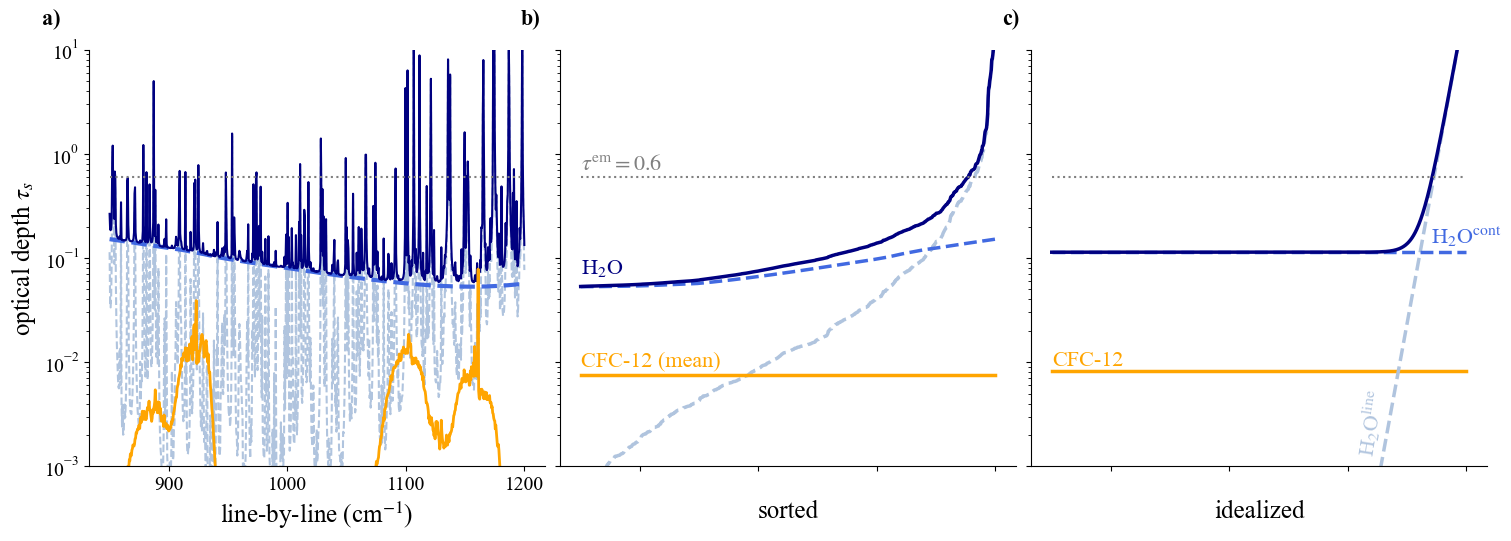

In [43]:
### H2O overlap schematic
# cfc12 is defined in Fig. 1
fig, axes = plt.subplots(1, 3, figsize = (15, 5), layout = 'compressed', sharey = True)

# plot line by line surface optical depth
axes[0].semilogy(cfc12_band, tau_line[:, 0], '--', color = 'lightsteelblue')
axes[0].semilogy(cfc12_band, tau_cont[:, 0], '--', color = 'royalblue', linewidth = 3)
axes[0].semilogy(cfc12_band, tau_line[:, 0] + tau_cont[:, 0], color = 'navy')
axes[0].semilogy(cfc12_band, cfc12_vmr*arts_tau_to_cumulative(cfc12_tau)[:, 0], color = 'orange', linewidth = 2)
axes[0].semilogy(cfc12_band, 0.6*np.ones(len(cfc12_band)), linestyle = 'dotted', color = 'grey')

width_param = 2.5
# plot sorted/mean absorption optical depths
axes[1].semilogy(cfc12_band, np.sort(tau_line[:, 0]), '--', color = 'lightsteelblue', linewidth = width_param)
axes[1].semilogy(cfc12_band, np.sort(tau_cont[:, 0]), '--', color = 'royalblue', linewidth = width_param)
axes[1].semilogy(cfc12_band, np.sort(tau_line[:, 0]) + np.sort(tau_cont[:, 0]), color = 'navy', linewidth = width_param)
axes[1].semilogy(cfc12_band, (np.trapz(cfc12_vmr*arts_tau_to_cumulative(cfc12_tau)[:, 0])/(cfc12_band[-1] - cfc12_band[0]))*np.ones(len(cfc12_band)), color = 'orange', linewidth = width_param)
axes[1].semilogy(cfc12_band, 0.6*np.ones(len(cfc12_band)), linestyle = 'dotted', color = 'grey')
axes[1].text(cfc12_band[0], 0.7, '$\\tau^{\mathrm{em}} = 0.6$', color = 'grey', fontsize = 16)
axes[1].text(cfc12_band[0], tau_nu(plev_ref, 198, cfc12_mmr)[0], 'CFC-12 (mean)', color = 'orange', fontsize = 16, va = 'bottom')
axes[1].text(cfc12_band[0], np.sort(tau_cont[:, 0])[0] + 10**-2, 'H$_2$O', color = 'navy', fontsize = 16, va = 'bottom')

# plot idealized surface optical depth
axes[2].semilogy(cfc12_band, tau_nu(plev_ref, 198, cfc12_mmr)[0]*np.ones(len(cfc12_band)), color = 'orange', linewidth = width_param)
axes[2].semilogy(cfc12_band, line_idealized_tau[:, 0], '--', color = 'lightsteelblue', linewidth = width_param)
axes[2].semilogy(cfc12_band, cont_idealized_tau[:, 0], '--', color = 'royalblue', linewidth = width_param)
axes[2].semilogy(cfc12_band, line_idealized_tau[:, 0] + cont_idealized_tau[:, 0], color = 'navy', linewidth = width_param)
axes[2].semilogy(cfc12_band, 0.6*np.ones(len(cfc12_band)), linestyle = 'dotted', color = 'grey')
axes[2].text(cfc12_band[0], tau_nu(plev_ref, 198, cfc12_mmr)[0] + 10**-4, 'CFC-12', color = 'orange', fontsize = 16, va = 'bottom')
axes[2].text(cfc12_band[-1], cont_idealized_tau[0, 0] + 10**-2, 'H$_2$O$^{\mathrm{cont}}$', color = 'royalblue', fontsize = 16, va = 'bottom', ha = 'center')
axes[2].text(1105, 1.2*10**-3, 'H$_2$O$^{\mathrm{line}}$', color = 'lightsteelblue', fontsize = 16, va = 'bottom',rotation = 81)
axes[2].set_ylim([10**-3, 10])
sns.despine()

# remove ticks

axes[1].set_xticks([900, 1000, 1100, 1200], labels = ['$~$', '$~$', '$~$', '$~$'])
axes[2].set_xticks([900, 1000, 1100, 1200], labels = ['$~$', '$~$', '$~$', '$~$'])

# labels
axes[0].set_ylabel("optical depth $\\tau_s$")
axes[0].set_xlabel("line-by-line (cm$^{-1}$)")
axes[1].set_xlabel("sorted")
axes[2].set_xlabel("idealized")

fig.text(0.03, 1.02, 'a)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.35, 1.02, 'b)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.67, 1.02, 'c)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')

plt.savefig("figures/h2o_overlap.pdf", bbox_inches = 'tight', dpi = 600)
plt.show()

### Figure A2
N$_2$O absorption coefficient idealization.

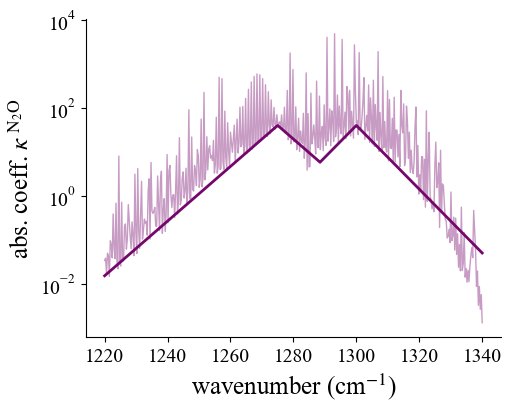

In [ ]:
idx1, idx2, idx3 = 180, 228, 270
k1, l1, nu1  = 40, 7, 1275 #65, 8
band3_1, abs1 = subband[:idx1], k(k1, nu1, l1, subband[:idx1]) #180
band3_2, abs2 = subband[idx1:idx2], k(k1, nu1, l1, subband[idx1:idx2])
k2, l2, nu2 = 40, 6, 1300 #65, 5
band3_3, abs3 = subband[idx2:idx3], k(k2, nu2, l2, subband[idx2:idx3]) #270
band3_4, abs4= subband[idx3:], k(k2, nu2, l2, subband[idx3:])

plev, phlev = konrad.utils.get_pressure_grids(1000e2, 1, 129)
atmosphere = konrad.atmosphere.Atmosphere(phlev)


# plot model figure
fig, ax = plt.subplots(1, 1, figsize = (5, 4), layout = 'compressed')

# plot modelled band3
ax.plot(subband, mass_abs_n2o[:, 39], linewidth = 1, color = band3_color, alpha = 0.4)
ax.plot(band3_1, abs1, linewidth = 2, color = band3_color)
ax.plot(band3_2, abs2, linewidth = 2, color = band3_color)
ax.plot(band3_3, abs3, linewidth = 2, color = band3_color)
ax.plot(band3_4, abs4, linewidth = 2, color = band3_color)

ax.set_ylabel("abs. coeff. $\kappa^\mathrm{~N_2O}$")

sns.despine(fig)
ax.set_xlabel("wavenumber (cm$^{-1}$)")
ax.set_yscale('log')
#fig.savefig("figures/n2o_spec.png", bbox_inches = 'tight', dpi = 300)

plt.show()

### Figure A3
Methane absorption coefficient

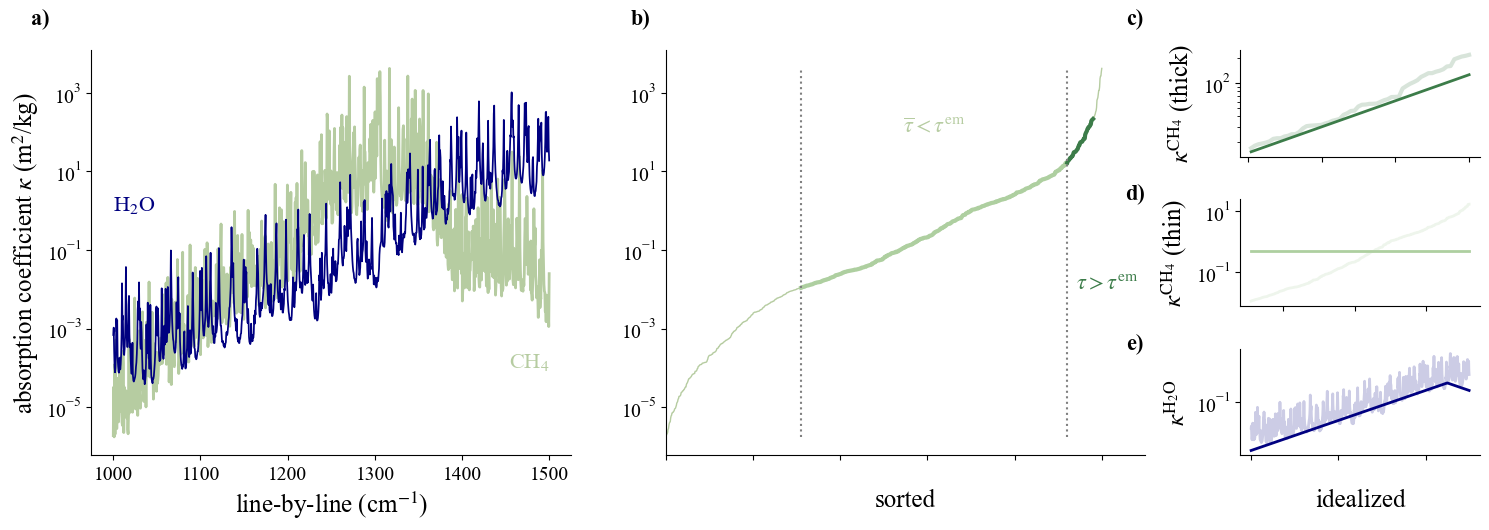

In [46]:
### Plot schematic
### Idealized coefficient parameters

# emission optical depths
t_em = 0.82
tau_em_h2o = 0.7

# H2O coefficient parameters
line_k, line_l = 3.8, 35

# CH4 coefficient parameters
param_array = np.array([[11, 42, 125, 14, 0.5]])
band1_start, band1_end = 310, 920 # band splits by index
band2_start, band2_end = 920, 980
band1 = ch4_band[band1_start:band1_end]
band2= ch4_band[band2_start:band2_end]
beta1, beta2 = 2, 2
k1 = param_array[0, 0]
l1 = param_array[0, 1]
k2 = param_array[0, 2]
l2 = param_array[0, 3]
band1_avg = param_array[0, 4]

# idealized absorption coefficients
k_ref_1 = k(k1, ch4_band[band1_end - 1], l1, band1)
k_ref_2 = k(k2, ch4_band[band2_end - 1], l2, band2)

# reference absorption coefficient
ref_idx = 39
abs_ref = np.sort(mass_abs_ch4[:, ref_idx])
sort_idx = sorted(range(len(mass_abs_ch4[:, ref_idx])), key = lambda k: mass_abs_ch4[:, ref_idx][k])

# turn vmr to mmr 
ch4_mmr = (16.04/28.8)*ch4_vmr
ch4_pi_mmr = (16.04/28.8)*ch4_pi_vmr
# colors
band_color = '#B6CCA1'
h2o_color = 'navy'
band1_color = '#AECFA0'
band2_color = '#3C7C49'
fig, axes = plt.subplots(figsize = (15,5), layout = 'tight', sharey = True)
fig.clf()

gs = gridspec.GridSpec(3, 3, width_ratios=[0.4, 0.4, 0.2])

# plot methane, water vapor absorption coefficients on axis 1
ax1 = fig.add_subplot(gs[:, 0])
ax1.semilogy(ch4_band, mass_abs_ch4[:, ref_idx], color = band_color, linewidth = 2)
ax1.semilogy(ch4_band, k_ref_line,  color = h2o_color, linewidth = 1.25)
ax1.set_ylabel("absorption coefficient $\kappa$ (m$^2$/kg)")
ax1.set_xlabel("line-by-line (cm$^{-1}$)")
ax1.text(ch4_band[-1], 10**-4, 'CH$_4$', color = band_color, horizontalalignment = 'right', fontsize = 16)
ax1.text(ch4_band[0], 10**0, 'H$_2$O', color = h2o_color, horizontalalignment = 'left', fontsize = 16)

# plot sorted CH4 coefficient on axis 2
ax2 = fig.add_subplot(gs[:, 1])
ax2.semilogy(ch4_band, abs_ref, color = band_color, linewidth = 1)
ax2.semilogy(band1, abs_ref[band1_start:band1_end], color = band1_color, linewidth = 3)
ax2.semilogy(band2, abs_ref[band2_start:band2_end], color = band2_color, linewidth = 3)
ax2.semilogy(band1[0]*np.ones(len(abs_ref)), np.linspace(np.min(abs_ref), np.max(abs_ref), len(abs_ref)), color = 'grey', linestyle = 'dotted')
ax2.semilogy(band2[0]*np.ones(len(abs_ref)), np.linspace(np.min(abs_ref), np.max(abs_ref), len(abs_ref)), color = 'grey', linestyle = 'dotted')
ax2.text(np.mean(band1), 10**2, '$\overline{\\tau} < \\tau^{\mathrm{em}}$', fontsize = 16, color = band_color, horizontalalignment = 'center')
ax2.text(band2[0] + 10, 10**-2, '$\\tau > \\tau^{\mathrm{em}}$', fontsize = 16, color = band2_color, horizontalalignment = 'left')
ax2.set_xlim([ch4_band[0], ch4_band[-1] + 50])
ax2.set_xticks([1000, 1100, 1200, 1300, 1400, 1500], labels = ['$~$', '$~$', '$~$', '$~$', '$~$', '$~$'])
ax2.set_xlabel("sorted")

# plot idealized optically-thin band on axis 3
ax3 = fig.add_subplot(gs[1, 2])
ax3.semilogy(band1, abs_ref[band1_start:band1_end], color = band1_color, alpha = 0.2, linewidth = 2)
ax3.semilogy(band1, 0.5*np.ones(len(band1)), color = band1_color, linewidth = 2)
ax3.set_ylabel("$\kappa^{\mathrm{CH_4}}$ (thin)")
ax3.set_xticks([1200, 1300, 1400], labels = ['$~$', '$~$', '$~$'])

# plot idealized optically-thick band on axis 4
ax4 = fig.add_subplot(gs[0, 2])
ax4.semilogy(band2, abs_ref[band2_start:band2_end], linewidth = 3, color = band2_color, alpha = 0.2)
ax4.semilogy(band2, k_ref_2, color = band2_color, linewidth = 2)
ax4.set_ylabel("$\kappa^{\mathrm{CH_4}}$ (thick)")
ax4.set_xticks([1460, 1470, 1480, 1490], labels = ['$~$', '$~$', '$~$', '$~$'])

# plot water vapor idealization on axis 5
ax5 = fig.add_subplot(gs[2, 2])
ax5.semilogy(ch4_band, k_ref_line,  color = h2o_color, linewidth = 2, alpha = 0.2)
ax5.semilogy(ch4_band, k(line_k, 1450, line_l, ch4_band), color = h2o_color, linewidth = 2)
ax5.set_xticks([1000, 1200, 1400], labels = ['$~$', '$~$', '$~$'])

ax5.set_xlabel("idealized")
ax5.set_ylabel("$\kappa^{\mathrm{H_2O}}$")

# labels
fig.text(0.03, 1.02, 'a)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.43, 1.02, 'b)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.76, 1.02, 'c)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.76, 0.67, 'd)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')
fig.text(0.76, 0.37, 'e)', color = 'black', horizontalalignment = 'center', fontsize = 16, weight = 'bold')

sns.despine()
plt.savefig("figures/methane_schematic.pdf", bbox_inches = 'tight', dpi = 300)
plt.show()
